# Churn patterns and early risk signals

Goal: understand how churn behaves in production and which signals from the first days of a new player predict that they will end up churned, in order to prepare the variable list for a baseline model.

**Contents**
1. Defining churn: use the production scores
2. Overview by tenant and a pipeline gap
3. The funnel: movements between bands (what drives them and what predicts them)
4. What the label means and when it is reliable
5. Early churn: signals from the first days of a new player (cohort, signals, AUC curve and SHAP)
6. Candidate variables for the baseline model

**Grouping convention**: this whole notebook groups and queries by
`tenant_id`, not `brand_id`. `brand_id` has no reliable history in the Gold
tables (empty in `gld_player_signals_daily` until 5 July 2026 and still
incomplete row by row today), while `tenant_id` has 100% of the history. Each tenant
currently maps to at most one `brand_id` (checked), so wherever something has to be
shown "by brand" it is labelled with that equivalent `brand_id`, but the
real work (aggregations, filters, time series) is always done on
`tenant_id`.

In [1]:
import os
os.environ["AWS_PROFILE"] = "javier-whizdom-prod-ds"

import boto3
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BUCKET = "whizdomai-eu-central-1-650177547431-datalake-gmntc-prod"
GOLD_PREFIX = "org/40-gold/"
DATA_CUTOFF = "2026-09-25"                 # last day of data included, so the results of this notebook are reproducible


def s3_duckdb():
    """DuckDB connection with the credentials of the SSO profile already loaded."""
    creds = boto3.Session(profile_name="javier-whizdom-prod-ds").get_credentials().get_frozen_credentials()
    con = duckdb.connect()
    con.sql("INSTALL httpfs; LOAD httpfs;")
    # Explicit limit: without it DuckDB tries to use almost all the RAM of the
    # machine in heavy queries.
    con.sql("SET memory_limit='4GB'")
    con.sql("SET threads=2")
    con.sql(f"""
        CREATE OR REPLACE SECRET s3_secret (
            TYPE S3, KEY_ID '{creds.access_key}', SECRET '{creds.secret_key}',
            SESSION_TOKEN '{creds.token}', REGION 'eu-central-1'
        );
    """)
    return con


def run_query(query, tables, year="*", month="*", day="*"):
    """Run `query` directly against S3, without downloading anything.
    tables: list of Gold tables used in the query.
    year/month/day: limit which partitions are read ("*" = the whole history)."""
    con = s3_duckdb()
    for t in tables:
        path = f"s3://{BUCKET}/{GOLD_PREFIX}{t}/{year}/{month}/{day}/data.parquet"
        con.sql(f"CREATE OR REPLACE VIEW {t} AS SELECT * FROM read_parquet('{path}')")
    result = con.sql(query).df()
    con.close()
    return result

## 1. Defining churn: use the production scores, not a home-made threshold

`gld_players` already includes `churn_band` (`Low`, `Moderate`, `High`, `Imminent`,
`Churned`), calculated by production. It is a rolling snapshot (it only keeps
~30 days), so it is useful to see the current state but not for time
series (Section 2 covers that with another table).

`churn_band` is only reliable when `has_sufficient_data = True`. Without that
filter, almost 85% of the rows are useless: 46% are empty
(registered players who have never bet, so there is no activity to score) and 39%
are an explicit `"Not Scored"` (players with bets but not enough
history to be scored, either new or already inactive). Filtering by
`has_sufficient_data = True` removes those two groups cleanly and only the
5 scored bands remain.

Section 4 explains what each band means.

In [2]:
SNAPSHOT_DAY = ("2026", "09", "15") 

players_snapshot = run_query(
    "SELECT tenant_id, brand_id, churn_band, lifecycle_stage, has_sufficient_data FROM gld_players",
    tables=["gld_players"], year=SNAPSHOT_DAY[0], month=SNAPSHOT_DAY[1], day=SNAPSHOT_DAY[2],
)

print("churn_band, unfiltered:")
print(players_snapshot["churn_band"].value_counts(dropna=False))
print()
print("churn_band, with has_sufficient_data=True:")
print(players_snapshot.loc[players_snapshot["has_sufficient_data"], "churn_band"].value_counts())

churn_band, unfiltered:
churn_band
              1683592
Not Scored    1440434
Churned        449455
Imminent        49415
High            38482
Low              7105
Moderate         6299
Name: count, dtype: int64

churn_band, with has_sufficient_data=True:
churn_band
Churned     449455
Imminent     49415
High         38482
Low           7105
Moderate      6299
Name: count, dtype: int64


### Mapping tenant_id to brand_id (to label, not to group)

Each tenant has, at most, one non-null `brand_id` (checked). It is only used to
put a readable label on charts; the `groupby` operations in the rest of the
notebook are still on `tenant_id`.

In [3]:
tenant_brand_map = (
    players_snapshot.loc[players_snapshot["brand_id"].notna(), ["tenant_id", "brand_id"]]
    .drop_duplicates()
    .set_index("tenant_id")["brand_id"]
    .astype(int)
)


def brand_label(tenant_id):
    """'brand N' if the brand is known, otherwise the short tenant_id."""
    if tenant_id in tenant_brand_map.index:
        return f"brand {tenant_brand_map[tenant_id]}"
    return f"tenant {tenant_id[:8]}"


print(f"{len(tenant_brand_map)} tenants with a known brand_id")
print(f"{len(tenant_brand_map)/len(players_snapshot['tenant_id'].drop_duplicates()) * 100:.2f}% with a known brand_id")

tenant_brand_map.head()

38 tenants with a known brand_id
90.48% with a known brand_id


tenant_id
057d7933-b29e-461d-865e-e3926bceee40    121
176aa995-e35f-47b1-812e-45cc5a53f080     75
31babf60-911f-44ac-84f8-a8feb5699390    120
3b1aecea-629c-48a5-81f0-3fb59e3b7e30     82
4cb5c6f8-a4cb-40d3-8a11-75fe9f817c80     64
Name: brand_id, dtype: int64

## 2. Overview by tenant: beware of a pipeline gap

`gld_brand_segments_daily` gives, per tenant and day, how many players are in
each band (`segment_kind='churn_band'`), with full history since
2025-04. Before comparing tenants we need to look at the whole series, not just
a snapshot.

In [4]:
segments_daily = run_query(
    f"""
    SELECT tenant_id, event_date, segment_band, player_count, pct_of_tenant_players
    FROM gld_brand_segments_daily
    WHERE segment_kind = 'churn_band' AND event_date <= DATE '{DATA_CUTOFF}'
    """,
    tables=["gld_brand_segments_daily"],
)
print(f"{len(segments_daily):,} rows, {segments_daily['tenant_id'].nunique()} tenants, "
      f"{segments_daily['event_date'].min().date()} to {segments_daily['event_date'].max().date()}")

top_tenants = segments_daily.groupby("tenant_id")["player_count"].sum().sort_values(ascending=False).head(6).index

96,592 rows, 42 tenants, 2025-04-01 to 2026-09-25


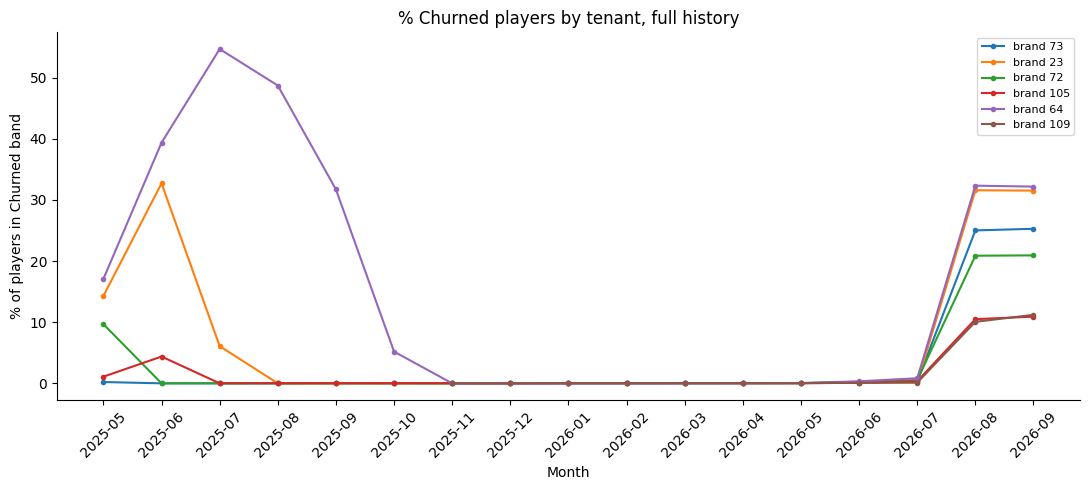

In [5]:
d = segments_daily[segments_daily["tenant_id"].isin(top_tenants) &(segments_daily["segment_band"] == "Churned")].copy()

d["month"] = d["event_date"].astype(str).str[:7]

monthly = (
    d.groupby(["tenant_id", "month"])["pct_of_tenant_players"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))

for tid in top_tenants:
    sub = monthly[monthly["tenant_id"] == tid].sort_values("month")
    ax.plot(
        sub["month"],
        sub["pct_of_tenant_players"],
        marker=".",
        label=brand_label(tid)
    )

ax.set_xlabel("Month")
ax.set_ylabel("% of players in Churned band")
ax.set_title("% Churned players by tenant, full history")

ax.tick_params(axis="x", rotation=45)

ax.legend(fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Check: is there really no churn in that period?

Before accepting the gap, we have to check it against real activity,
not just against another derived table. We take a sample of players
marked as `Low` (low risk) in the middle of the "dead" period (2026-06-15,
brand 23) and check whether they placed any real bet in the previous 60
days, using `gld_player_gaming_daily` (independent from
`gld_player_risk_daily` and `gld_brand_segments_daily`).

In [6]:
TENANT_EJEMPLO = "8132d267-493f-4d16-895d-7867c1563c10"
FECHA_MUESTRA = ("2026", "06", "15")

low_players = run_query(
    "SELECT player_id, recency_pressure, churn_propensity_raw FROM gld_player_risk_daily WHERE tenant_id = '"
    + TENANT_EJEMPLO + "' AND churn_band = 'Low'",
    tables=["gld_player_risk_daily"], year=FECHA_MUESTRA[0], month=FECHA_MUESTRA[1], day=FECHA_MUESTRA[2],
)
muestra = low_players["player_id"].sample(800, random_state=0).tolist()
ids_sql_muestra = ",".join(str(i) for i in muestra)

con = s3_duckdb()
paths_actividad = [f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_gaming_daily/2026/{m:02d}/*/data.parquet" for m in [4, 5, 6]]
paths_sql = "[" + ",".join(f"'{p}'" for p in paths_actividad) + "]"
actividad = con.sql(f"""
    SELECT player_id, COUNT(*) days_with_bet
    FROM read_parquet({paths_sql})
    WHERE tenant_id = '{TENANT_EJEMPLO}' AND player_id IN ({ids_sql_muestra})
      AND event_date BETWEEN DATE '2026-04-17' AND DATE '2026-06-15'
    GROUP BY player_id
""").df()
con.close()

sin_actividad = len(muestra) - len(actividad)
print(f"{len(low_players):,} players in band 'Low' on {FECHA_MUESTRA[2]}/{FECHA_MUESTRA[1]}/{FECHA_MUESTRA[0]}")
print(f"from a sample of {len(muestra)}: {sin_actividad} ({sin_actividad/len(muestra)*100:.0f}%) with no real bet in the previous 60 days")

57,524 players in band 'Low' on 15/06/2026
from a sample of 800: 558 (70%) with no real bet in the previous 60 days


**Confirmed: it is a real pipeline failure, not a misreading.** 70% of
the sample had gone 60 days without betting and was still marked as `Low` risk.
Three concrete examples, looking for their last real bet in the whole
available history:

| player_id | last real bet | days without playing (at 2026-06-15) |
|---|---|---|
| 2160644 | 2025-11-02 | ~225 |
| 12535808 | 2025-11-19 | ~208 |
| 7989253 | 2025-08-28 | ~291 |

Almost 10 months without betting and classified as low risk. `recency_pressure`
and `churn_propensity_raw` for this group were also abnormally low
that day (means of 0.4 and 0.002 respectively, when they should reflect such a
long inactivity), so the problem is not only the band cut: the
input signal was also wrong that day. So there is no need to
ask whether it is an error: it is one, and it is documented with
independent evidence (real betting activity, not another derived score).

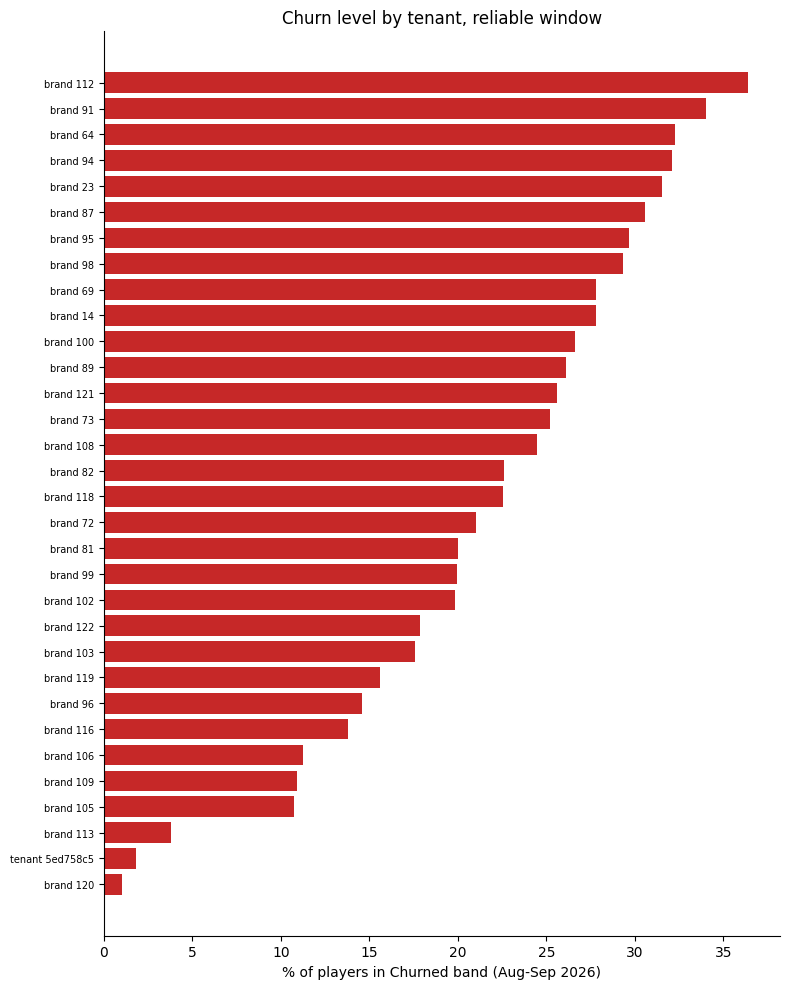

In [7]:
VENTANA_FIABLE_INICIO = "2026-08-15"
TAMANIO_MINIMO = 50 

valid = segments_daily[segments_daily["event_date"] >= VENTANA_FIABLE_INICIO].copy()
sizes = valid.groupby("tenant_id")["player_count"].mean()
tenants_ok = sizes[sizes >= TAMANIO_MINIMO].index

churned_ok = valid[valid["tenant_id"].isin(tenants_ok) & (valid["segment_band"] == "Churned")]
ranking_churn = churned_ok.groupby("tenant_id")["pct_of_tenant_players"].mean().mul(100).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(range(len(ranking_churn)), ranking_churn.values, color="#c62828")
ax.set_yticks(range(len(ranking_churn)))
ax.set_yticklabels([brand_label(t) for t in ranking_churn.index], fontsize=7)
ax.set_xlabel("% of players in Churned band (Aug-Sep 2026)")
ax.set_title("Churn level by tenant, reliable window")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

Real differences between tenants, not noise: from 1% to 36% of players in the
`Churned` band, with most between 15% and 30%. This justifies looking at churn by tenant
instead of using one single global number.

## 3. The funnel: movements between bands

`gld_brand_segments_movements` gives, per tenant and day, how many players
moved from one band to another (`band_kind='churn_band'`). It is restricted to the
same reliable window as Section 2, adding up all tenants to see the general
shape of the funnel.

It is drawn as **two directed graphs**, one per direction: one for the
movements that **raise** the risk and another for those that **lower** it. Bands
are placed in a row, from lower to higher risk (`Low` to `Churned`), and each arrow is a
transition, with a width proportional to the square root of the number of movements and **the
same scale in both graphs**, so that they can be compared. Compared with the Sankey of the
previous version, each band appears only once, jumps over several
bands are visible (for example `Low -> High`) and small flows do not disappear.

Movements from and to `Not Scored` are not drawn: entering or leaving
scoring is not a rise or a fall in risk (they are in the matrix below).

216,657 rows, 2025-04-15 to 2026-09-25


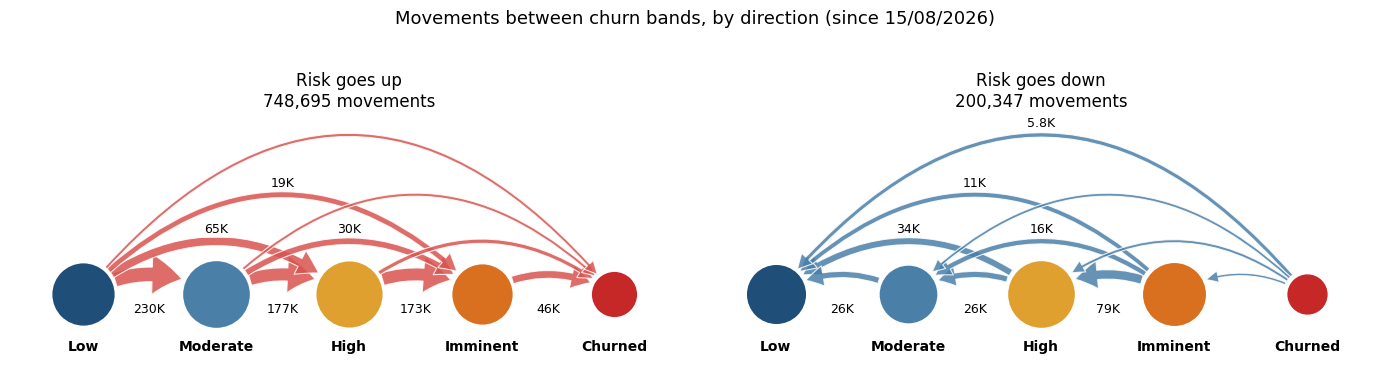

Outside the graphs: 8,720 movements from Not Scored and 14,199 to Not Scored (entering or leaving scoring is not a rise or a fall in risk).


In [8]:
movements = run_query(
    f"""
    SELECT tenant_id, event_date, from_band, to_band, player_count
    FROM gld_brand_segments_movements
    WHERE band_kind = 'churn_band' AND event_date <= DATE '{DATA_CUTOFF}'
    """,
    tables=["gld_brand_segments_movements"],
)
print(f"{len(movements):,} rows, {movements['event_date'].min().date()} to {movements['event_date'].max().date()}")

movements_ok = movements[movements["event_date"] >= VENTANA_FIABLE_INICIO]
flows = movements_ok.groupby(["from_band", "to_band"])["player_count"].sum().reset_index()
flows = flows[flows["from_band"] != flows["to_band"]]

from matplotlib.patches import FancyArrowPatch

BANDAS = ["Low", "Moderate", "High", "Imminent", "Churned"]            # from lower to higher risk (Not Scored is handled separately)
COLOR_BANDA = {"Low": "#1f4e79", "Moderate": "#4a7fa8", "High": "#e0a030", "Imminent": "#d9701f", "Churned": "#c62828"}
POS = {b: i for i, b in enumerate(BANDAS)}

riesgo = flows[flows["from_band"].isin(BANDAS) & flows["to_band"].isin(BANDAS)]
up = riesgo[riesgo["to_band"].map(POS) > riesgo["from_band"].map(POS)]
down = riesgo[riesgo["to_band"].map(POS) < riesgo["from_band"].map(POS)]
VMAX = riesgo["player_count"].max()                                     # same width scale in both graphs


def fmt(v):
    return f"{v / 1000:.0f}K" if v >= 10_000 else f"{v / 1000:.1f}K"


def grafo(ax, fl, color, titulo):
    """Directed graph with the bands in a row, from lower to higher risk. Arrow width ~ square root of the number of movements;
    node area ~ movements entering and leaving. Transitions with more than 2% of the movements are labelled."""
    total = fl["player_count"].sum()
    mov = pd.concat([fl.groupby("from_band")["player_count"].sum(), fl.groupby("to_band")["player_count"].sum()], axis=1).fillna(0).sum(axis=1)
    area = {b: 450 + 2000 * np.sqrt(mov.get(b, 0) / mov.max()) for b in BANDAS}
    for b in BANDAS:
        ax.scatter(POS[b], 0, s=area[b], color=COLOR_BANDA[b], zorder=3, edgecolor="white", linewidth=1.5)
        ax.text(POS[b], -0.34, b, ha="center", va="top", fontsize=10, fontweight="bold")
    for _, r in fl.sort_values("player_count", ascending=False).iterrows():             # thick ones at the back
        x1, x2 = POS[r["from_band"]], POS[r["to_band"]]
        dist = abs(x2 - x1)
        ancho = 1.5 + 9 * np.sqrt(r["player_count"] / VMAX)
        curva = 0.3 + 0.1 * (dist - 1)                                                   # more curvature the further apart: separates arrows of the same node
        radio = lambda b: np.sqrt(area[b]) / 2 + 2                                       # in points: the arrow starts and ends outside the node
        ax.add_patch(FancyArrowPatch((x1, 0), (x2, 0), connectionstyle=f"arc3,rad={-curva if x2 > x1 else curva}",
                                     arrowstyle=f"simple,tail_width={ancho},head_width={2.4 * ancho + 4},head_length={1.5 * ancho + 6}",
                                     mutation_scale=1, facecolor=color, edgecolor="white", linewidth=0.8, alpha=0.85,
                                     shrinkA=radio(r["from_band"]), shrinkB=radio(r["to_band"]), zorder=2))
        if r["player_count"] >= 0.02 * total:
            y_txt, va = (-0.06, "top") if dist == 1 else (curva * dist / 2 + 0.04, "bottom")
            ax.text((x1 + x2) / 2, y_txt, fmt(r["player_count"]), ha="center", va=va, fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9), zorder=4)
    ax.set_xlim(-0.55, 4.55)
    ax.set_ylim(-0.6, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{titulo}\n{total:,.0f} movements", fontsize=12)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
grafo(axes[0], up, "#d9534f", "Risk goes up")
grafo(axes[1], down, "#4a7fa8", "Risk goes down")
fig.suptitle(f"Movements between churn bands, by direction (since {pd.Timestamp(VENTANA_FIABLE_INICIO):%d/%m/%Y})", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

entran = flows.loc[flows["from_band"] == "Not Scored", "player_count"].sum()
salen = flows.loc[flows["to_band"] == "Not Scored", "player_count"].sum()
print(f"Outside the graphs: {entran:,} movements from Not Scored and {salen:,} to Not Scored (entering or leaving scoring is not a rise or a fall in risk).")

In [9]:
NODOS = ["Not Scored"] + BANDAS
matriz_flujos = flows.pivot(index="from_band", columns="to_band", values="player_count").reindex(index=NODOS, columns=NODOS).fillna(0).astype(int)
matriz_flujos.index.name, matriz_flujos.columns.name = "from (row)", "to (column)"
matriz_flujos

to (column),Not Scored,Low,Moderate,High,Imminent,Churned
from (row),,,,,,
Not Scored,0,2853,1269,1813,1675,1110
Low,7178,0,229969,64554,19182,1155
Moderate,2002,26286,0,176800,30051,1190
High,2840,34360,25843,0,173399,6842
Imminent,2179,11233,15790,78748,0,45553
Churned,0,5786,770,1230,301,0


**Risk goes up much more than it goes down**: 696K movements towards higher risk against 211K towards lower risk, about 3.3 to 1. The Sankeys of the previous version scaled each panel separately and hid this. The largest upward flows are single steps (`Low -> Moderate` 212K, `High -> Imminent` 171K and `Moderate -> High` 163K), but there are also jumps: `Low -> High` moves 54K.

**`Imminent` is a stage players pass through, not a dead end**: of the movements leaving `Imminent`, 72% go down a band (106K, mostly to `High`, 80K) and only 28% end in `Churned` (41K). There is also a way back from `Churned` (`Churned -> Low`, 5.6K), although small.

These are movements (a player can move several times), not distinct players.

### What moves players between bands?

Within `Low` to `Imminent`, the band is a cut of the `churn_score` (0-25-50-75-100) and the `churn_score` is `0.50 · recency + 0.30 · frequency drop + 0.20 · value drop`, capped to 0-100 (columns `recency_pressure`, `frequency_decline` and `value_decline`). Since the formula is known, each movement from one day to the next can be **decomposed**: the contribution of each component is its weight times how much that component has changed, and the one that pushes most in the direction of the movement is the **dominant** one. There is nothing to model and there is no circularity here: the formula is exactly what we want to explain.

We use the daily movements of all scored players since 2 August (stable production labels, see Section 4). Movements from and to `Churned` do not depend on the score (`Churned` = 31 or more days without betting) and are shown separately.

In [10]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)

DIR_MOV = "../data/09_external/movimientos_bandas"                      
FICHERO_MOV = f"{DIR_MOV}/movimientos_20260802_20260924.parquet"
os.makedirs(DIR_MOV, exist_ok=True)

if os.path.exists(FICHERO_MOV):
    mov = pd.read_parquet(FICHERO_MOV)
else:
    con = s3_duckdb()

    def foto(d):
        """State of each scored player on day d (risk bands and Churned) with the components of the churn_score."""
        ruta = f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/{d:%Y}/{d:%m}/{d:%d}/data.parquet"
        return con.sql(f"""
            SELECT tenant_id, player_id, churn_band, churn_score, recency_pressure, frequency_decline, value_decline,
                   days_since_bet, bets_today
            FROM read_parquet('{ruta}') WHERE churn_band IN ('Low', 'Moderate', 'High', 'Imminent', 'Churned')
        """).df()

    fechas_mov = pd.date_range("2026-08-01", "2026-09-24")              
    movs, ayer = [], foto(fechas_mov[0])
    for d in fechas_mov[1:]:
        hoy = foto(d)
        m = hoy.merge(ayer, on=["tenant_id", "player_id"], suffixes=("", "_ant"))
        movs.append(m[m["churn_band"] != m["churn_band_ant"]].assign(fecha=d))      # changes band from one day to the next
        ayer = hoy
    con.close()
    mov = pd.concat(movs, ignore_index=True)
    mov.to_parquet(FICHERO_MOV)

ORDEN = {"Low": 1, "Moderate": 2, "High": 3, "Imminent": 4}
PESOS = {"recency": ("recency_pressure", 0.5), "frequency": ("frequency_decline", 0.3), "value": ("value_decline", 0.2)}
en_score = mov[mov["churn_band"].isin(ORDEN) & mov["churn_band_ant"].isin(ORDEN)].copy()      # movements between the 4 risk bands


def formula(df, sufijo=""):
    return sum(w * df[c + sufijo] for c, w in PESOS.values()).clip(0, 100)


print(f"{len(mov):,} movements over {mov['fecha'].nunique()} days, from {mov[['tenant_id', 'player_id']].drop_duplicates().shape[0]:,} distinct players")
print(f"between the 4 risk bands: {len(en_score):,} ({len(en_score) / len(mov) * 100:.0f}%) | with Churned (entering or leaving): {len(mov) - len(en_score):,}")
print(f"churn_score = 0.5 recency + 0.3 frequency + 0.2 value (capped to 0-100): holds in "
      f"{((en_score['churn_score'] - formula(en_score)).abs() < 0.1).mean() * 100:.2f}% of today's states and in "
      f"{((en_score['churn_score_ant'] - formula(en_score, '_ant')).abs() < 0.1).mean() * 100:.2f}% of yesterday's")

1,321,723 movements over 54 days, from 159,596 distinct players
between the 4 risk bands: 1,210,435 (92%) | with Churned (entering or leaving): 111,288
churn_score = 0.5 recency + 0.3 frequency + 0.2 value (capped to 0-100): holds in 100.00% of today's states and in 100.00% of yesterday's


### Dominant component of each movement

For each movement between the 4 risk bands: contribution of each component (in `churn_score` points) and dominant component, the one that pushes most in the direction of the movement. For each transition, the table gives the percentage of movements where each one dominates, the median score jump and how many days the player had gone without betting.

In [11]:
for nombre, (col, peso) in PESOS.items():
    en_score[f"contrib_{nombre}"] = peso * (en_score[col] - en_score[col + "_ant"])       # score points contributed by each component
en_score["up"] = en_score["churn_band"].map(ORDEN) > en_score["churn_band_ant"].map(ORDEN)
en_score["d_score"] = en_score["churn_score"] - en_score["churn_score_ant"]
signo = np.where(en_score["up"], 1.0, -1.0)
aportes = en_score[[f"contrib_{n}" for n in PESOS]].to_numpy() * signo[:, None]          # positive = pushes in the direction of the movement
en_score["dominant"] = np.array(list(PESOS))[aportes.argmax(axis=1)]
en_score["transition"] = en_score["churn_band_ant"] + " -> " + en_score["churn_band"]

print("Dominant component, over all movements (%):")
print((pd.crosstab(en_score["up"].map({True: "up", False: "down"}), en_score["dominant"], normalize="index") * 100).round(1).to_string())
print(f"\nScore jump per movement: median {en_score['d_score'].abs().median():.1f} points; less than 5 points in {(en_score['d_score'].abs() < 5).mean() * 100:.1f}% (not threshold noise)")
valor_dom = en_score[en_score["dominant"] == "value"]
print(f"Movements dominated by value with value_decline > 100: {(valor_dom['value_decline'] > 100).mean() * 100:.0f}%")

tabla = (en_score.groupby(["up", "transition"])
         .agg(movements=("d_score", "size"), median_jump=("d_score", "median"),
              pct_recency=("dominant", lambda s: (s == "recency").mean() * 100),
              pct_frequency=("dominant", lambda s: (s == "frequency").mean() * 100),
              pct_value=("dominant", lambda s: (s == "value").mean() * 100),
              days_without_bet=("days_since_bet", "median"),
              pct_bet_yesterday_or_today=("days_since_bet", lambda s: (s <= 1).mean() * 100))
         .reset_index().sort_values(["up", "movements"], ascending=[False, False]))
tabla["direction"] = np.where(tabla["up"], "up", "down")
tabla = tabla.set_index(["direction", "transition"]).drop(columns="up")
tabla = tabla.astype({c: "float64" for c in tabla.columns if c != "movements"}).round(1)
tabla


Dominant component, over all movements (%):
dominant  frequency  recency  value
up                                 
down           20.2     57.1   22.7
up             19.8     63.9   16.3

Score jump per movement: median 26.3 points; less than 5 points in 3.6% (not threshold noise)
Movements dominated by value with value_decline > 100: 44%


movements  median_jump  pct_recency  pct_frequency  pct_value  days_without_bet  pct_bet_yesterday_or_today
direction transition                                                                                                                       
up        High -> Imminent         216273         28.7         37.9           37.4       24.7               6.0                         5.2
          Low -> Moderate          210808         16.7         88.7            3.6        7.8               2.0                        28.0
          Moderate -> High         197698         16.7         89.7            4.9        5.5               3.0                        10.3
          Low -> High               56302         50.0         35.5           50.6       13.9               7.0                        22.2
          Moderate -> Imminent      35258         52.6          9.8           46.4       43.8               3.0                        16.5
          Low -> Imminent           19313         83.3          1.9           15.6       82.6               1.0                        58.6
down      Imminent -> High         148998        -34.7         42.7           28.6       28.7               3.0                        46.5
          High -> Low              119675        -45.0         78.9           16.6        4.6               1.0                        89.4
          Moderate -> Low           86416        -17.9         65.7            8.4       25.9               1.0                        90.8
          High -> Moderate          65054        -25.6         54.8           27.7       17.4               1.0                        71.4
          Imminent -> Moderate      32771        -50.0         46.2           23.0       30.8               1.0                        61.5
          Imminent -> Low           21869        -83.3         26.5            2.5       71.1               1.0                        97.2

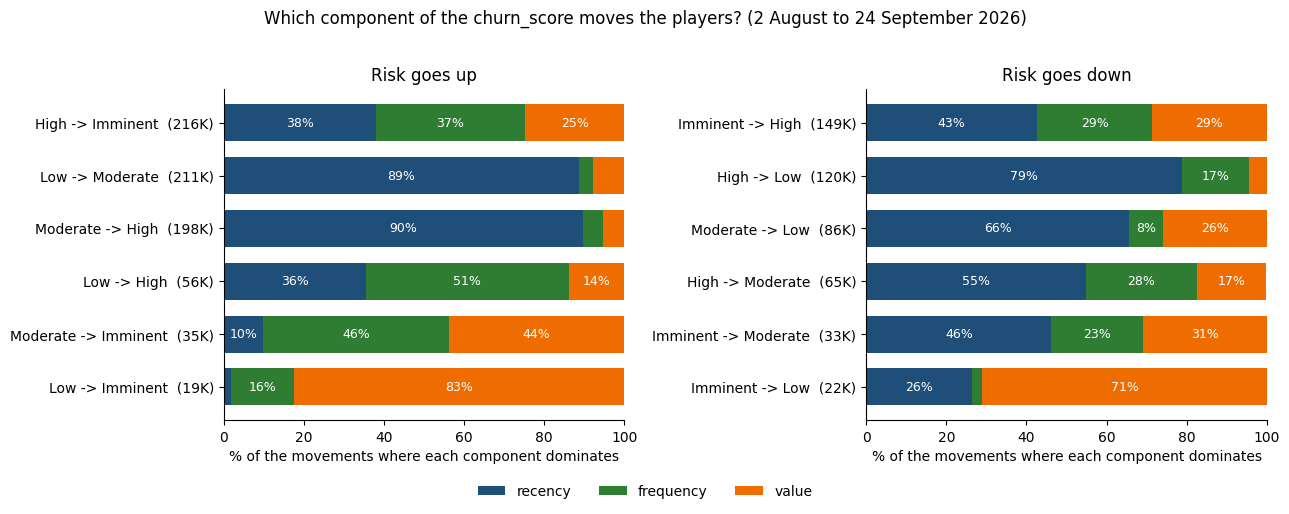

In [12]:
COLOR_COMP = {"recency": "#1f4e79", "frequency": "#2e7d32", "value": "#ef6c00"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for ax, direction in zip(axes, ["up", "down"]):
    g = tabla.loc[direction]
    izq = np.zeros(len(g))
    for comp in PESOS:
        ax.barh(range(len(g)), g[f"pct_{comp}"], left=izq, color=COLOR_COMP[comp], label=comp, height=0.7)
        for i, (v, l) in enumerate(zip(g[f"pct_{comp}"], izq)):
            if v >= 8:
                ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=9)
        izq += g[f"pct_{comp}"].to_numpy()
    ax.set_yticks(range(len(g)))
    ax.set_yticklabels([f"{t}  ({n / 1000:.0f}K)" for t, n in zip(g.index, g["movements"])], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of the movements where each component dominates")
    ax.set_title("Risk goes up" if direction == "up" else "Risk goes down")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.07), frameon=False)
fig.suptitle("Which component of the churn_score moves the players? (2 August to 24 September 2026)", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Movements from and to `Churned`

`Churned` does not depend on the score but on a clock: 31 or more days without betting. That is why they are looked at separately.

In [13]:
entran = mov[mov["churn_band"] == "Churned"]
salen = mov[mov["churn_band_ant"] == "Churned"]
churned = pd.DataFrame({
    "enter Churned": [len(entran), entran["days_since_bet"].median(), (entran["days_since_bet"] == 31).mean() * 100, (entran["bets_today"] > 0).mean() * 100],
    "leave Churned": [len(salen), salen["days_since_bet"].median(), np.nan, (salen["bets_today"] > 0).mean() * 100],
}, index=["movements", "days without betting (median) that day", "% exactly at 31 days", "% with a bet that same day"]).round(1)
print("Destination of those who leave Churned (%):", (salen["churn_band"].value_counts(normalize=True) * 100).round(0).astype(int).to_dict())
churned


Destination of those who leave Churned (%): {'Low': 72, 'Moderate': 15, 'High': 13, 'Imminent': 0}


,enter Churned,leave Churned
movements,72661.0,38627.0
days without betting (median) that day,31.0,1.0
% exactly at 31 days,91.6,NaN
% with a bet that same day,0.1,0.0


### Check of the frequency and value components

The other two components can be rebuilt with the formulas of the codebook. `value_decline` is not capped, so we look at when it goes above 100.

In [14]:
con = s3_duckdb()
val = con.sql(f"""
    SELECT value_decline, frequency_decline, ggr_eur_l7d, ggr_eur_l90d, active_days_l7d, active_days_l30d
    FROM read_parquet('s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/2026/09/10/data.parquet')
    WHERE churn_band IN ('Low', 'Moderate', 'High', 'Imminent')
""").df()
con.close()
valor_calc = 100 * np.maximum(0, 1 - (val["ggr_eur_l7d"] / 7) / (val["ggr_eur_l90d"] / 90))
frec_calc = 100 * np.maximum(0, 1 - (val["active_days_l7d"] / 7) / (val["active_days_l30d"] / 30))
ok_v, ok_f = np.isfinite(valor_calc), np.isfinite(frec_calc)
print(f"10 September, {len(val):,} scored players in the 4 risk bands")
print(f"value_decline = 100 · max(0, 1 - (GGR 7d / 7) / (GGR 90d / 90)): matches in {((valor_calc[ok_v] - val['value_decline'][ok_v]).abs() < 0.5).mean() * 100:.1f}% of {ok_v.sum():,}")
print(f"frequency_decline = 100 · max(0, 1 - (active days 7d / 7) / (active days 30d / 30)): matches in {((frec_calc[ok_f] - val['frequency_decline'][ok_f]).abs() < 0.5).mean() * 100:.1f}% of {ok_f.sum():,}")
mas100 = val[val["value_decline"] > 100]
print(f"value_decline > 100: {len(mas100):,} players ({len(mas100) / len(val) * 100:.1f}%), maximum {val['value_decline'].max():,.0f}. Sign of the 7-day and 90-day GGR in those cases:")
pd.crosstab(np.sign(mas100["ggr_eur_l7d"]).map({-1: "GGR 7d < 0", 1: "GGR 7d > 0"}), np.sign(mas100["ggr_eur_l90d"]).map({-1: "GGR 90d < 0", 1: "GGR 90d > 0"}))

10 September, 100,965 scored players in the 4 risk bands
value_decline = 100 · max(0, 1 - (GGR 7d / 7) / (GGR 90d / 90)): matches in 100.0% of 96,942
frequency_decline = 100 · max(0, 1 - (active days 7d / 7) / (active days 30d / 30)): matches in 100.0% of 95,198
value_decline > 100: 10,840 players (10.7%), maximum 16,032,063. Sign of the 7-day and 90-day GGR in those cases:


ggr_eur_l90d,GGR 90d < 0,GGR 90d > 0
ggr_eur_l7d,,
GGR 7d < 0,0,5058
GGR 7d > 0,5782,0


**The formula holds exactly**, so the decomposition explains 100% of the movements between the 4 risk bands (1.21M of the 1.32M in total between 2 August and 24 September; the rest enter or leave `Churned`). These are movements, not distinct players: 160K players move at least once.

**Recency leads, but it runs out quickly**
- `recency_pressure` only takes the values 0, 33, 67 and 100: it rises during the first three days without betting and **saturates at 3 days**. That is why the one-step jumps from `Low` and `Moderate` (`Low -> Moderate` and `Moderate -> High`, 34% of the movements between risk bands) are almost only recency (89% and 90%): one more day without betting, +16.7 score points.
- After that point recency no longer moves anything. `High -> Imminent`, the largest flow (216K), is shared between recency (38%), frequency (37%) and value (25%), with a median of 6 days without betting.
- The jumps over several bands (`Low -> High`, `Moderate -> Imminent` and `Low -> Imminent`) are driven by frequency and value, mostly value (83% in `Low -> Imminent`).

**Falls are mostly players betting again.** In 72% of the falls the last bet was yesterday or today, and recency dominates those going to `Low` (79% in `High -> Low`, 66% in `Moderate -> Low`). Falls from `Imminent` are more mixed and in `Imminent -> Low` value dominates (71%).

**`Churned` is a clock, not a score.** 92% of the entries happen exactly when the player reaches 31 days without betting. The exits (39K, 72% towards `Low`) happen the day after the player bets again (0% with a bet on that same day): the score lags one day behind the activity.

**Beware of the value component.** It is not capped (it reaches millions) and it exceeds 100 for 11% of the scored players, always because the 7-day and 90-day GGR have opposite signs: players who won that week after a losing streak, or who have started losing after a winning streak. In 44% of the movements dominated by value it exceeds 100, and those jumps take the player straight to `Imminent` without a gradual drop in value. They are not threshold noise: the median jump is 26 score points and only 3.6% of the movements are smaller than 5 points.

**To predict rises that last** (next step) this mechanical part has to be discounted: someone who has gone 3 days without betting already has 50 score points from recency alone.

### Predicting band rises and falls

The decomposition tells us *how* players move (almost all of it is recency, frequency and value mechanics). Now we measure how much of that mechanics can be anticipated and **which behaviour adds information on top of the current state**.

- **Rows**: each player in `Low`, `Moderate`, `High` or `Imminent` on an origin day (one every 3 days, from 2 August to 16 September), with the signals of that day and their band 7 days later.
- **Two targets**: **up** (origin `Low`, `Moderate` or `High`): 7 days later the player is in a higher-risk band, including `Churned`. **Down** (origin `Moderate`, `High` or `Imminent`): 7 days later the player is in a lower-risk band. We look at the state after 7 days and not at the daily movements, which are very noisy (34% are reversed within 3 days).
- **Evaluation**: trained on the origins up to 23 August and evaluated on the origins from 1 September (the gap of one week prevents the training labels from reaching the test set). The AUC that matters is the one **within each origin band**, because the global AUC is inflated just by knowing the band.
- **Models** (gradient boosting): band + days without betting; **state** (band, score and its components, days without betting, streak, score change since yesterday and `deposit_recency_score`); state + **behaviour** (activity, money, session rhythm and risk signals); and the previous one + **trend** (change against the previous 7 days).

In [15]:
import warnings
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from scipy.stats import spearmanr

DIR_MOV = "../data/09_external/movimientos_bandas"
FICHERO_TRANS = f"{DIR_MOV}/transiciones_h7.parquet"
os.makedirs(DIR_MOV, exist_ok=True)

# Signals of the origin day, by group. The state is what the score already knows; the rest is behaviour.
ESTADO_RAW = ["churn_score", "recency_pressure", "frequency_decline", "value_decline", "days_since_bet",
              "current_active_streak_days", "deposit_recency_score"]
ACTIVIDAD = ["active_days_l7d", "active_days_l30d", "active_days_l90d", "bets_l7d", "bets_l30d", "bets_l90d", "sessions_l7d",
             "sessions_l30d", "play_secs_l7d", "play_secs_l30d", "tp_avg_sessions_per_active_day", "tp_max_sessions_single_day",
             "tp_avg_session_gap_hours", "tp_avg_session_duration_secs", "games_breadth_l30d", "tenure_days", "engagement_score"]
DINERO_RAW = ["wagered_eur_l7d", "wagered_eur_l30d", "wagered_eur_l90d", "ggr_eur_l7d", "ggr_eur_l30d", "ggr_eur_l90d",
              "deposits_eur_l7d", "deposits_eur_l30d", "deposits_eur_l90d", "withdrawals_eur_l30d", "bonus_granted_eur_l30d",
              "avg_bet_eur_l7d", "avg_bet_eur_l30d", "hold_pct_l30d", "value_score_eur", "wagered_real_eur_l30d", "wagered_bonus_eur_l30d"]
COMPORTAMIENTO = ["deposit_frequency_score", "stake_escalation", "bet_z_score", "session_len_z", "betting_aggression_score",
                  "risk_appetite_score", "rg_loss_chasing_30d", "rg_deposit_velocity", "rg_night_play_ratio", "net_loss_velocity",
                  "session_intensity_score", "risk_score", "tp_night_index", "tp_weekend_index", "tp_business_hours_ratio",
                  "tp_hourly_entropy", "sessions_with_bonus_l30d"]
PRIOR = ["prior_churn_score", "prior_active_days_l7d", "prior_bets_l7d", "prior_wagered_eur_l7d", "prior_ggr_eur_l7d",
         "prior_deposits_eur_l7d", "prior_avg_bet_eur_l7d", "prior_engagement_score", "prior_risk_score"]
COLS_TRANS = ESTADO_RAW + ACTIVIDAD + DINERO_RAW + COMPORTAMIENTO + PRIOR
ORIGENES = pd.date_range("2026-08-02", "2026-09-16", freq="3D")       

if os.path.exists(FICHERO_TRANS):
    trans = pd.read_parquet(FICHERO_TRANS)
else:
    con = s3_duckdb()
    ruta = lambda d: f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/{d:%Y}/{d:%m}/{d:%d}/data.parquet"
    partes = []
    for t in ORIGENES:
        hoy = con.sql(f"""SELECT tenant_id, player_id, churn_band AS banda, {", ".join(COLS_TRANS)} FROM read_parquet('{ruta(t)}')
                          WHERE churn_band IN ('Low', 'Moderate', 'High', 'Imminent')""").df()
        dentro_de_7 = con.sql(f"""SELECT tenant_id, player_id, churn_band AS banda_h FROM read_parquet('{ruta(t + pd.Timedelta(days=7))}')
                                  WHERE churn_band IN ('Low', 'Moderate', 'High', 'Imminent', 'Churned')""").df()
        partes.append(hoy.merge(dentro_de_7, on=["tenant_id", "player_id"], how="left").assign(origen=t))
    con.close()
    trans = pd.concat(partes, ignore_index=True)
    trans[[c for c in trans.columns if trans[c].dtype == "float64"]] = trans[[c for c in trans.columns if trans[c].dtype == "float64"]].astype("float32")
    trans.to_parquet(FICHERO_TRANS)

ORD = {"Low": 1, "Moderate": 2, "High": 3, "Imminent": 4, "Churned": 5}
trans["b0"], trans["b7"] = trans["banda"].map(ORD), trans["banda_h"].map(ORD)
sin_dato = trans["b7"].isna().mean() * 100
trans = trans[trans["b7"].notna()].copy()                                 # players who are no longer scored 7 days later
trans["up"] = (trans["b7"] > trans["b0"]).astype(int)
trans["down"] = (trans["b7"] < trans["b0"]).astype(int)

# Derived signals
trans["d_score_1d"] = trans["churn_score"] - trans["prior_churn_score"]
bono = trans["wagered_real_eur_l30d"] + trans["wagered_bonus_eur_l30d"]
trans["bonus_share_30d"] = np.where(bono > 0, trans["wagered_bonus_eur_l30d"] / bono.replace(0, np.nan), np.nan)
TENDENCIA_DEF = {"d_active_days_7d": ("active_days_l7d", "prior_active_days_l7d"), "d_bets_7d": ("bets_l7d", "prior_bets_l7d"),
                 "d_wagered_7d": ("wagered_eur_l7d", "prior_wagered_eur_l7d"), "d_ggr_7d": ("ggr_eur_l7d", "prior_ggr_eur_l7d"),
                 "d_deposits_7d": ("deposits_eur_l7d", "prior_deposits_eur_l7d"), "d_avg_bet_7d": ("avg_bet_eur_l7d", "prior_avg_bet_eur_l7d"),
                 "d_engagement": ("engagement_score", "prior_engagement_score"), "d_risk": ("risk_score", "prior_risk_score")}
for nombre, (ahora, antes) in TENDENCIA_DEF.items():
    trans[nombre] = trans[ahora] - trans[antes]

ESTADO = ["b0"] + ESTADO_RAW + ["d_score_1d"]
DINERO = [c for c in DINERO_RAW if c not in ("wagered_real_eur_l30d", "wagered_bonus_eur_l30d")] + ["bonus_share_30d"]
TENDENCIA = list(TENDENCIA_DEF)
COLS_MODELO = ESTADO + ACTIVIDAD + DINERO + COMPORTAMIENTO
GRUPO = {**{c: "state" for c in ESTADO}, **{c: "activity" for c in ACTIVIDAD}, **{c: "money" for c in DINERO},
         **{c: "behaviour and risk" for c in COMPORTAMIENTO}, **{c: "trend" for c in TENDENCIA}}
NOMBRE_BANDA = {1: "Low", 2: "Moderate", 3: "High", 4: "Imminent"}

muestra = trans.sample(100_000, random_state=0)
print(f"{len(trans):,} rows from {trans['origen'].nunique()} origin days ({sin_dato:.1f}% discarded because they are not scored 7 days later)")
print("Players per origin band (daily mean):", (trans.groupby("b0").size() / trans["origen"].nunique()).round(0).astype(int).rename(NOMBRE_BANDA).to_dict())
print("% that 7 days later are in a higher band (up) or a lower band (down), by origin band:")
print(trans.groupby("b0")[["up", "down"]].mean().mul(100).round(1).rename(index=NOMBRE_BANDA).to_string())
print(f"\ndeposit_recency_score vs days_since_bet: Spearman correlation {spearmanr(muestra['deposit_recency_score'], muestra['days_since_bet'])[0]:.2f} (it is bet recency, it is treated as state)")

1,658,140 rows from 16 origin days (0.0% discarded because they are not scored 7 days later)
Players per origin band (daily mean): {'Low': 19937, 'Moderate': 12065, 'High': 33186, 'Imminent': 38445}
% that 7 days later are in a higher band (up) or a lower band (down), by origin band:
            up  down
b0                  
Low       65.8   0.0
Moderate  63.4  19.0
High      43.1  19.4
Imminent  19.8  27.5

deposit_recency_score vs days_since_bet: Spearman correlation -0.95 (it is bet recency, it is treated as state)


### Models and AUC

For each target and origin band. `band only (rate)` predicts the historical proportion of the band, which is why its AUC within each band is 0.50.

In [16]:
es_train, es_test = trans["origen"] <= "2026-08-23", trans["origen"] >= "2026-09-01"       # between them, a gap of one week
TAREAS = {"up": ("up", [1, 2, 3]), "down": ("down", [2, 3, 4])}
TENANT = trans["tenant_id"].astype("category").cat.codes
MODELOS = {"band + days without betting": ["b0", "days_since_bet"], "state": ESTADO,
           "state + behaviour": COLS_MODELO, "+ trend": COLS_MODELO + TENDENCIA}


def gbm(**kw):
    return HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, max_leaf_nodes=31, l2_regularization=1.0,
                                          early_stopping=True, random_state=0, **kw)


filas, por_fecha, modelos = [], [], {}
for tarea, (y, origenes) in TAREAS.items():
    d = trans[trans["b0"].isin(origenes)]
    tr, te = d[es_train.reindex(d.index)], d[es_test.reindex(d.index)]
    print(f"{tarea}: training {len(tr):,} rows, test {len(te):,} | % that go {tarea} in the test: {te[y].mean() * 100:.1f}%")
    pred = {"band only (rate)": te["b0"].map(tr.groupby("b0")[y].mean()).to_numpy()}
    for nombre, cols in MODELOS.items():
        m = gbm().fit(tr[cols], tr[y])
        pred[nombre] = m.predict_proba(te[cols])[:, 1]
        modelos[(tarea, nombre)] = m
    tenant_cols = COLS_MODELO + ["tenant"]                                    # variant with the tenant as a categorical variable
    tr_t, te_t = tr.assign(tenant=TENANT.loc[tr.index]), te.assign(tenant=TENANT.loc[te.index])
    m = gbm(categorical_features=[len(tenant_cols) - 1]).fit(tr_t[tenant_cols], tr_t[y])
    pred["state + behaviour + tenant"] = m.predict_proba(te_t[tenant_cols])[:, 1]
    for nombre, p in pred.items():
        fila = {"task": tarea, "model": nombre, "AUC": roc_auc_score(te[y], p), "AP": average_precision_score(te[y], p)}
        for b in origenes:
            mk = (te["b0"] == b).to_numpy()
            fila[f"AUC {NOMBRE_BANDA[b]}"] = roc_auc_score(te.loc[mk, y], p[mk])
        filas.append(fila)
        for fecha, g in te.assign(p=p).groupby("origen"):
            por_fecha.append({"task": tarea, "model": nombre, "origin": fecha.strftime("%d/%m"), "AUC": roc_auc_score(g[y], g["p"])})

resultados = pd.DataFrame(filas).set_index(["task", "model"])
orden_modelos = ["band only (rate)"] + list(MODELOS) + ["state + behaviour + tenant"]
resultados = resultados.loc[[(t, m) for t in TAREAS for m in orden_modelos]].round(3)
resultados

up: training 534,432 rows, test 380,929 | % that go up in the test: 55.9%
down: training 663,282 rows, test 504,508 | % that go down in the test: 22.2%


AUC     AP  AUC Low  AUC Moderate  AUC High  AUC Imminent
task model                                                                                   
up   band only (rate)             0.635  0.645    0.500         0.500     0.500           NaN
     band + days without betting  0.816  0.834    0.697         0.654     0.822           NaN
     state                        0.850  0.866    0.788         0.708     0.868           NaN
     state + behaviour            0.862  0.876    0.800         0.723     0.893           NaN
     + trend                      0.862  0.876    0.801         0.724     0.893           NaN
     state + behaviour + tenant   0.863  0.877    0.801         0.725     0.894           NaN
down band only (rate)             0.573  0.258      NaN         0.500     0.500         0.500
     band + days without betting  0.835  0.591      NaN         0.633     0.779         0.854
     state                        0.857  0.686      NaN         0.707     0.843         0.873
     state + behaviour            0.867  0.725      NaN         0.722     0.854         0.890
     + trend                      0.867  0.725      NaN         0.723     0.854         0.890
     state + behaviour + tenant   0.868  0.726      NaN         0.723     0.854         0.893

In [17]:
por_fecha = pd.DataFrame(por_fecha).pivot_table(index=["task", "model"], columns="origin", values="AUC", sort=False)
mejora = pd.concat({t: por_fecha.loc[(t, "state + behaviour")] - por_fecha.loc[(t, "state")] for t in TAREAS}, axis=1).T
print("AUC improvement when adding behaviour to the state, by origin date of the test:")
mejora.round(3)

AUC improvement when adding behaviour to the state, by origin date of the test:


origin,01/09,04/09,07/09,10/09,13/09,16/09
up,0.015,0.016,0.015,0.016,0.006,0.005
down,0.010,0.010,0.010,0.010,0.007,0.009


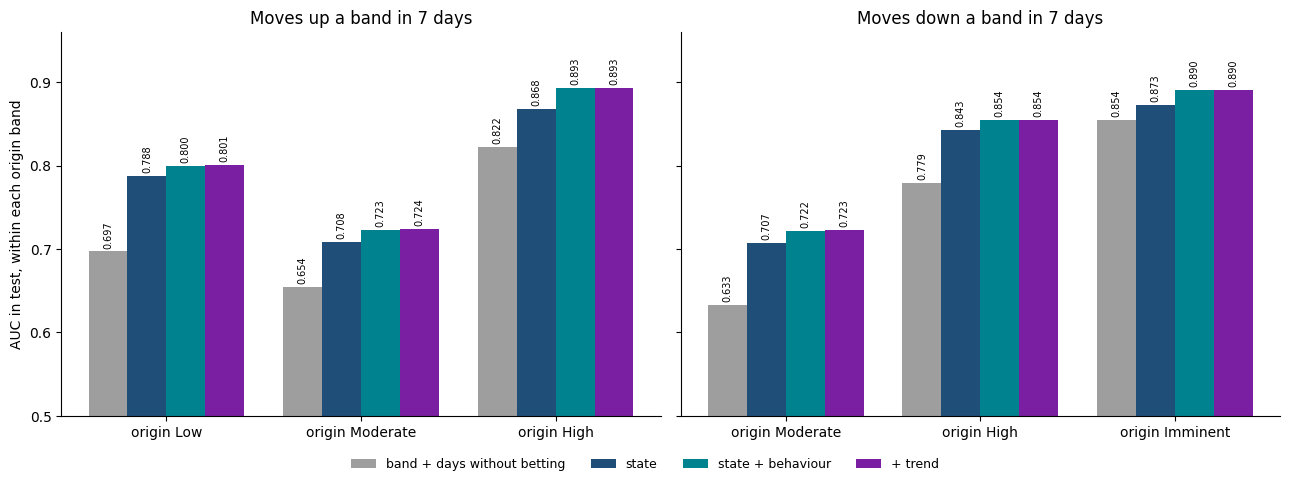

In [18]:
COLOR_MODELO = {"band + days without betting": "#9e9e9e", "state": "#1f4e79", "state + behaviour": "#00838f", "+ trend": "#7b1fa2"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, (tarea, (y, origenes)) in zip(axes, TAREAS.items()):
    ancho = 0.2
    for k, modelo in enumerate(COLOR_MODELO):
        vals = [resultados.loc[(tarea, modelo), f"AUC {NOMBRE_BANDA[b]}"] for b in origenes]
        pos = np.arange(len(origenes)) + (k - 1.5) * ancho
        ax.bar(pos, vals, width=ancho, color=COLOR_MODELO[modelo], label=modelo)
        for x, v in zip(pos, vals):
            ax.text(x, v + 0.004, f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=90)
    ax.set_xticks(range(len(origenes)))
    ax.set_xticklabels([f"origin {NOMBRE_BANDA[b]}" for b in origenes])
    ax.set_ylim(0.5, 0.96)
    ax.set_title("Moves up a band in 7 days" if tarea == "up" else "Moves down a band in 7 days")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("AUC in test, within each origin band")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.tight_layout()
plt.show()

### What behaviour adds, with SHAP

We explain the state + behaviour model on 4,000 test players per target and origin band. First, how much of the prediction is state and how much is behaviour, and then the behaviour signals that weigh most, with the effect of a high value versus a low one (▲ = a high value increases the probability of going up or down, ▼ = it decreases it).

In [19]:
warnings.filterwarnings("ignore", message="IProgress not found")
import shap

MUESTRA_SHAP = 4000
imp_shap, efecto = {}, {}
for tarea, (y, origenes) in TAREAS.items():
    explicador = shap.TreeExplainer(modelos[(tarea, "state + behaviour")])
    d = trans[trans["b0"].isin(origenes) & es_test]
    for b in origenes:
        mu = d[d["b0"] == b].sample(MUESTRA_SHAP, random_state=0)
        sv = pd.DataFrame(explicador.shap_values(mu[COLS_MODELO]), columns=COLS_MODELO, index=mu.index)
        imp_shap[(tarea, b)] = sv.abs().mean()
        for c in COLS_MODELO:
            x = mu[c]
            bajo, alto = x.quantile(1 / 3), x.quantile(2 / 3)
            if alto > bajo:                                                   # effect = mean SHAP of the top third minus that of the bottom third
                efecto[(tarea, b, c)] = sv.loc[x >= alto, c].mean() - sv.loc[x <= bajo, c].mean()
imp = pd.DataFrame(imp_shap)
reparto = (imp.groupby(imp.index.map(GRUPO)).sum() / imp.sum() * 100).round(0).astype(int).loc[["state", "activity", "money", "behaviour and risk"]]
reparto.columns = [f"{t}: {NOMBRE_BANDA[b]}" for t, b in reparto.columns]
print("Split of the SHAP importance (%) between the state and each behaviour group:")
reparto

Split of the SHAP importance (%) between the state and each behaviour group:


,up: Low,up: Moderate,up: High,down: Moderate,down: High,down: Imminent
state,70,66,71,76,74,71
activity,14,15,14,11,13,13
money,10,12,10,9,9,12
behaviour and risk,5,6,5,4,4,4


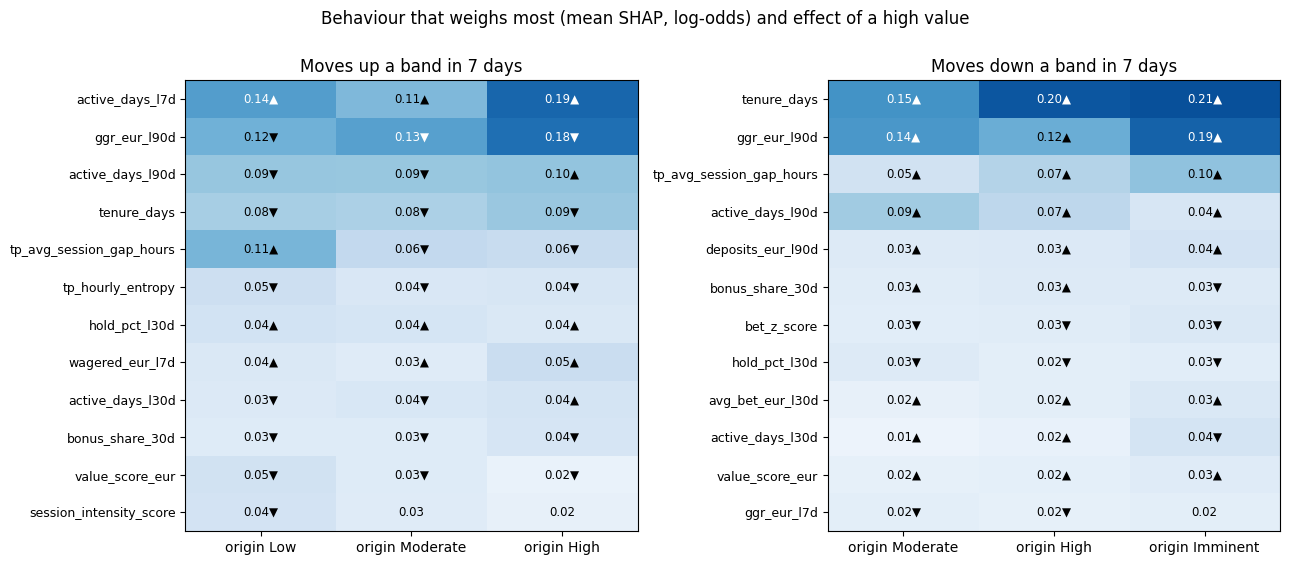

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, (tarea, (y, origenes)) in zip(axes, TAREAS.items()):
    M = pd.concat({NOMBRE_BANDA[b]: imp_shap[(tarea, b)] for b in origenes}, axis=1)
    M = M.loc[[c for c in M.index if GRUPO[c] != "state"]]                   # behaviour only
    top = M.mean(axis=1).sort_values(ascending=False).head(12).index
    M = M.loc[top]
    ax.imshow(M.values, cmap="Blues", aspect="auto", vmin=0, vmax=0.24)
    ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels([f"origin {c}" for c in M.columns])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top, fontsize=9)
    for i, c in enumerate(top):
        for j, b in enumerate(origenes):
            e = efecto.get((tarea, b, c), np.nan)
            ax.text(j, i, f"{M.iloc[i, j]:.2f}{'' if np.isnan(e) else '▲' if e > 0 else '▼'}", ha="center", va="center", fontsize=8.5,
                    color="white" if M.iloc[i, j] > 0.13 else "black")
    ax.set_title("Moves up a band in 7 days" if tarea == "up" else "Moves down a band in 7 days")
fig.suptitle("Behaviour that weighs most (mean SHAP, log-odds) and effect of a high value", y=1.0)
plt.tight_layout()
plt.show()

**The current state predicts almost everything.** With only the band and the days without betting, the AUC within each band already goes from 0.63 to 0.85. The full state (score and components, streak, score change since yesterday and `deposit_recency_score`) raises it to 0.71-0.87, and the state accounts for 66% to 76% of the SHAP importance. Going up or down a band in 7 days is mostly recency, frequency and value mechanics.

**Behaviour adds little, but consistently**: +0.011 to +0.025 of AUC within each band (the maximum, +0.025, in origin `High` of "up"), positive on all 6 test dates (in "up" only +0.006 and +0.005 on the last two). The trend (change against the previous 7 days) adds nothing (±0.001), and the tenant almost nothing (+0.001 to +0.003, unlike in early churn).

**Which behaviour weighs** (partial effect, with the state already discounted):
- **Tenure and usual activity**: `tenure_days`, `active_days_l90d` and `ggr_eur_l90d`. Veteran players, with more active days in 90 days and more accumulated GGR (they have lost more) **go down more and up less** (the exception is `active_days_l90d` in origin `High` of "up"): they recover more and deteriorate less.
- **Session rhythm**: `tp_avg_session_gap_hours` (typical hours between sessions). A long usual gap favours falls in all three bands: someone who usually comes back after a pause does come back. In `Low`, a long usual gap goes with more rises (the ups and downs of someone who does not play every day), and in `Moderate` and `High` with fewer.
- **`active_days_l7d` increases the probability of going up** in all three bands: with the same state, someone who plays every day changes band sooner when they miss a few days (probably because their base frequency is higher, so a miss weighs more in the frequency drop; this is a hypothesis, it has not been checked).
- **Money and bonuses weigh little**: `bonus_share_30d` and the 90-day deposits are worth 0.03-0.04, far from their role in early churn, where the bonus was the main signal.

**To prioritise actions**: the players who recover by themselves are veterans with usual activity; those who need intervention are those who do not come back on their own, that is, low tenure and little activity in 90 days.

**Caveats**: the effects are partial (conditioned on the state) and not causal; the test covers only 16 origin days; the production score lags one day; and the same players appear on several origin days.

## 4. Before modelling: what the label means and when it is reliable

The early churn study (Section 5) uses the production `churn_band` as its label. Before that we need to know three things: what each band means, whom production scores and since when the history is stable.

In [21]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 20)

con = s3_duckdb()
SIG_0924 = f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/2026/09/24/data.parquet"
bandas = con.sql(f"""
    SELECT churn_band AS band, COUNT(*) AS players,
           ROUND(MIN(churn_score), 1) AS score_min, ROUND(MAX(churn_score), 1) AS score_max,
           MIN(days_since_bet) AS days_without_bet_min, MEDIAN(days_since_bet) AS days_without_bet_median,
           MAX(days_since_bet) AS days_without_bet_max
    FROM read_parquet('{SIG_0924}')
    WHERE churn_band IS NOT NULL AND churn_band <> ''
    GROUP BY 1 ORDER BY score_min
""").df()
bandas

,band,players,score_min,score_max,days_without_bet_min,days_without_bet_median,days_without_bet_max
0,Not Scored,1466728,0.0,100.0,0,332.0,545
1,Low,10030,0.0,25.0,0,1.0,14
2,Churned,459350,9.5,100.0,31,266.0,545
3,Moderate,8683,25.0,50.0,0,2.0,30
4,High,38627,50.0,75.0,0,7.0,30
5,Imminent,43198,75.0,100.0,0,15.0,30


**What each band means** (`gld_player_signals_daily`, 24 September 2026):
- `Low`, `Moderate`, `High` and `Imminent` are cuts of the `churn_score` (0-25, 25-50, 50-75, 75-100) and only exist for players with **30 days or less without betting**.
- `Churned` starts at **31 days without betting**, whatever the score. It is the definition of "30 days in a row without playing".
- `Not Scored` means there is not enough data to score. The codebook asks for at least 3 bets and 14 days of tenure (`sufficiency.min_bets = 3`, `min_tenure_days = 14`).
- `lifecycle_stage` is something else: `Churned` is 91 or more days without betting (Dormant: 31 to 90).

In [22]:
P_0924 = f"s3://{BUCKET}/{GOLD_PREFIX}gld_players/2026/09/24/data.parquet"
puntuacion = con.sql(f"""
    SELECT CASE WHEN first_bet_at IS NULL THEN 'no bet at all'
                WHEN d <= 7 THEN '0-7' WHEN d <= 14 THEN '8-14' WHEN d <= 30 THEN '15-30'
                WHEN d <= 60 THEN '31-60' WHEN d <= 90 THEN '61-90' ELSE '91+' END AS days_since_first_bet,
           COUNT(*) AS players,
           ROUND(100.0 * AVG((churn_band IS NULL OR churn_band = '')::INT), 1) AS pct_empty_band,
           ROUND(100.0 * AVG((churn_band = 'Not Scored')::INT), 1) AS pct_not_scored,
           ROUND(100.0 * AVG((churn_band = 'Churned')::INT), 1) AS pct_band_churned,
           ROUND(100.0 * AVG((lifecycle_stage = 'Churned')::INT), 1) AS pct_lifecycle_churned
    FROM (SELECT *, date_diff('day', CAST(first_bet_at AS DATE), DATE '2026-09-24') AS d FROM read_parquet('{P_0924}'))
    GROUP BY 1 ORDER BY MIN(CASE WHEN first_bet_at IS NULL THEN 9999 ELSE d END)
""").df()
puntuacion

,days_since_first_bet,players,pct_empty_band,pct_not_scored,pct_band_churned,pct_lifecycle_churned
0,0-7,14981,0.0,100.0,0.0,0.0
1,8-14,14399,0.0,100.0,0.0,0.0
2,15-30,29750,0.0,89.5,0.0,0.0
3,31-60,55213,0.0,78.5,9.8,0.0
4,61-90,71695,0.0,82.7,11.0,0.0
5,91+,1791559,0.0,70.5,24.7,91.5
6,no bet at all,1769132,97.9,2.1,0.0,0.0


**Whom production scores.** The empty `churn_band` values are exactly the players who have never bet (none of the players with bets has an empty band). Among new players, `Not Scored` is the norm: 100% of those with 0 to 14 days since their first bet and still 78% at 31-60 days. These are most of the players who leave early, so the study only applies to the players who get scored. `Churned` (band) appears from 31 days on, and `lifecycle_stage = Churned`, which needs more than 90 days without betting, cannot happen for a new player in this period.

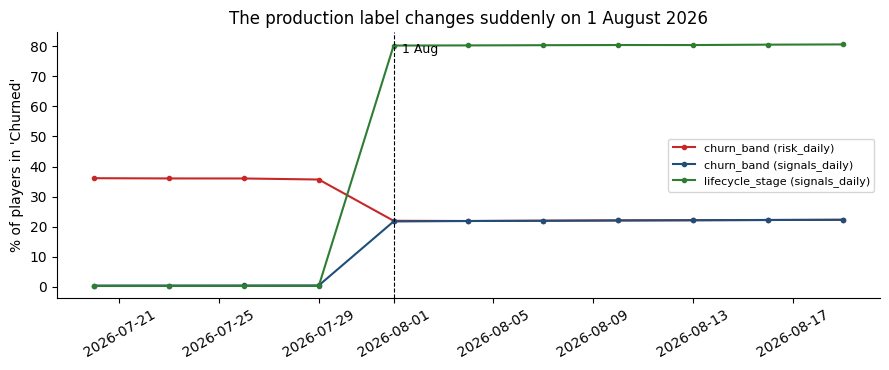

In [23]:
fechas = pd.date_range("2026-07-20", "2026-08-20", freq="3D")
filas = []
for f in fechas:
    d = f"{f:%Y}/{f:%m}/{f:%d}"
    riesgo = con.sql(f"SELECT 100 * AVG((churn_band = 'Churned')::INT) FROM read_parquet('s3://{BUCKET}/{GOLD_PREFIX}gld_player_risk_daily/{d}/data.parquet')").fetchone()[0]
    sen = con.sql(f"SELECT 100 * AVG((churn_band = 'Churned')::INT), 100 * AVG((lifecycle_stage = 'Churned')::INT) FROM read_parquet('s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/{d}/data.parquet')").fetchone()
    filas.append({"date": f, "churn_band (risk_daily)": riesgo, "churn_band (signals_daily)": sen[0], "lifecycle_stage (signals_daily)": sen[1]})
estabilidad = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(9, 3.8))
for c, color in zip(estabilidad.columns[1:], ["#c62828", "#1f4e79", "#2e7d32"]):
    ax.plot(estabilidad["date"], estabilidad[c], marker="o", markersize=3, color=color, label=c)
ax.axvline(pd.Timestamp("2026-08-01"), color="black", linestyle="--", linewidth=0.8)
ax.text(pd.Timestamp("2026-08-01"), ax.get_ylim()[1] * 0.96, "  1 Aug", fontsize=9, va="top")
ax.set_ylabel("% of players in 'Churned'")
ax.set_title("The production label changes suddenly on 1 August 2026")
ax.legend(fontsize=8, loc="center right")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
SIG_COLS = ["risk_score", "deposit_recency_score", "deposit_frequency_score", "engagement_score", "session_intensity_score",
            "churn_score", "active_days_l7d", "active_days_l30d", "bets_l7d", "play_secs_l7d", "wagered_eur_l7d",
            "deposits_eur_l30d", "value_score_eur", "stake_escalation", "rg_deposit_velocity"]


def pct_igual(d1, d2):
    """% of players with exactly the same value (tolerance 0.1%) in each signal between two days."""
    sel = ", ".join(f'a."{c}" AS a_{c}, b."{c}" AS b_{c}' for c in SIG_COLS)
    ruta = lambda d: f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/{d}/data.parquet"
    df = con.sql(f"SELECT {sel} FROM read_parquet('{ruta(d1)}') a JOIN read_parquet('{ruta(d2)}') b USING (tenant_id, player_id)").df()
    return pd.Series({c: np.mean(np.isclose(df[f"a_{c}"].astype(float), df[f"b_{c}"].astype(float), atol=1e-3, rtol=1e-3, equal_nan=True)) * 100
                      for c in SIG_COLS})


cambio = pd.DataFrame({"% same, 30 to 31 Jul": pct_igual("2026/07/30", "2026/07/31"),
                       "% same, 31 Jul to 1 Aug": pct_igual("2026/07/31", "2026/08/01")}).round(0).astype(int)
con.close()
cambio

,"% same, 30 to 31 Jul","% same, 31 Jul to 1 Aug"
risk_score,98,98
deposit_recency_score,99,4
deposit_frequency_score,99,99
engagement_score,98,98
session_intensity_score,98,98
churn_score,98,7
active_days_l7d,98,98
active_days_l30d,98,98
bets_l7d,98,98
play_secs_l7d,98,98


**Since when it is stable.** On 1 August 2026 the production labels change suddenly (`Churned` in `lifecycle_stage` goes from 0.3% to 80%, `churn_band` in `risk_daily` from 36% to 22%) and, among the signals, only `deposit_recency_score` and `churn_score` (for inactive players and players without a deposit). The rest of the signals are identical on both sides of the cut (98-99%).

**Consequences for the study design:**
- The label is only read on dates **from 1 August**.
- Since it is measured on day 60 of each player, the cohort is the players with a first bet between 2 June and 26 July (their day 60 falls between 1 August and 24 September).
- The signals cannot be `churn_score` (it is the formula of the label) or `deposit_recency_score` (its definition changed). They are calculated from the event tables (`gaming_daily`, `payments_daily`), which are consistent over the whole period.

## 5. Early churn: signals from the first days of a new player

**Question.** A new player has been playing for k days. With what we know about those days (active days, time played, deposits, how much they bet with bonus...), can we predict whether production will mark them as `Churned` on their day 60? And how much does the prediction improve as days go by (k = 1, 3, 7, 14, 21 and 28)?

**Definitions**
- **New player**: first bet between 2 June and 26 July 2026 (see Section 4).
- **Gold tables**: `gld_players` defines the cohort (date of the first bet); `gld_player_gaming_daily` (gaming), `gld_player_payments_daily` (deposits and withdrawals) and `gld_player_bonus_daily` (bonuses granted, released and expired, and active bonus balance) give the signals; `gld_player_signals_daily` only gives the label.
- **Signals**: only what happened on days 0 to k since the first bet (day 0 = day of the first bet), calculated from the three event tables (gaming, payments and bonuses).
- **Label**: production `churn_band` on day 60 (`gld_player_signals_daily`). `Churned` (31 or more days without betting) versus `Low`, `Moderate`, `High` and `Imminent`.
- **Population**: only players scored on day 60 (`has_sufficient_data`). The model answers: *if this player gets scored, will they end up `Churned`?* We also study the population of those who are still playing (they bet in the 7 days before k), where the prediction is not trivial.
- **Evaluation**: trained on the players who joined earlier (70%) and evaluated on those who joined later (30%), not at random.

In [25]:
from datetime import date, timedelta


def _meses_entre(d1, d2):
    """List of (year, month) that cover [d1, d2], without repeats."""
    meses, actual = [], date(d1.year, d1.month, 1)
    while actual <= d2:
        meses.append((actual.year, actual.month))
        actual = date(actual.year + 1, 1, 1) if actual.month == 12 else date(actual.year, actual.month + 1, 1)
    return meses


# Pilot parameters
K = 7                                   # days of observation since the first bet
DIAS_ETIQUETA = 60                      # the label is the production churn_band on this day of life
COHORTE_INI, COHORTE_FIN = date(2026, 6, 2), date(2026, 7, 26)   # date of the first bet
CACHE = "../data/09_external/early_churn_pilot"                  # intermediate results (not versioned)
os.makedirs(CACHE, exist_ok=True)

con = s3_duckdb()
cohorte = con.sql(f"""
    SELECT tenant_id, player_id, CAST(first_bet_at AS DATE) AS fb
    FROM read_parquet('s3://{BUCKET}/{GOLD_PREFIX}gld_players/2026/09/24/data.parquet')
    WHERE first_bet_at >= TIMESTAMP '{COHORTE_INI}' AND first_bet_at < TIMESTAMP '{COHORTE_FIN + timedelta(days=1)}'
""").df()
con.close()
cohorte["fb"] = pd.to_datetime(cohorte["fb"]).dt.date
print(f"new players (first bet between {COHORTE_INI} and {COHORTE_FIN}): {len(cohorte):,}")
print(f"duplicates (tenant, player): {cohorte.duplicated(['tenant_id', 'player_id']).sum()}")

new players (first bet between 2026-06-02 and 2026-07-26): 130,668
duplicates (tenant, player): 0


### Check: batches that are not new players

A tenant can register thousands of already existing players at once (a migration). Those players are not new and would contaminate the cohort. We flag the tenant-days with a number of sign-ups greater than 5 times the tenant median.

In [26]:
altas = cohorte.groupby(["tenant_id", "fb"]).size().rename("n").reset_index()
altas["tenant_median"] = altas.groupby("tenant_id")["n"].transform("median")
altas["pico"] = (altas["n"] > 5 * altas["tenant_median"]) & (altas["n"] >= 300)
picos = altas[altas["pico"]].copy()
picos["tenant"] = picos["tenant_id"].map(brand_label)

clave_pico = set(zip(picos["tenant_id"], picos["fb"]))
cohorte["pico"] = [(t, f) in clave_pico for t, f in zip(cohorte["tenant_id"], cohorte["fb"])]
print(f"tenant-days with a sign-up spike: {len(picos)}, with {int(cohorte['pico'].sum()):,} players ({cohorte['pico'].mean() * 100:.1f}% of the cohort)")
picos[["tenant", "fb", "n", "tenant_median"]].sort_values("n", ascending=False).head(10)

tenant-days with a sign-up spike: 1, with 702 players (0.5% of the cohort)


,tenant,fb,n,tenant_median
122,brand 100,2026-06-14,702,123.0


### Signals from the first K days

The data per player and day (day 0 = day of the first bet, up to day 28) for gaming, payments and bonuses are read from S3 **only once** and saved in `CACHE`. From there, `features_k(cohorte, k)` calculates the signals of a player using **only** days 0 to k, for any k. Deposits and bonuses are looked at from 14 days before the first bet (a welcome bonus can be granted before betting).

**Bonuses** (`gld_player_bonus_daily`, with full history since 2025): bonuses granted, released and expired (number and amount in EUR), amount wagered towards the wagering requirement, days since the last bonus granted, whether the player had a bonus before the first bet and what share of the already resolved bonuses was released (`bonus_n_released / (bonus_n_released + bonus_n_expired)`). The **active bonus balance** (`active_bonus_balance_eur`) is also calculated (`bonus_balance_max_eur`, `days_with_active_bonus`), but it is left out of the study: it is not stable over time (check below). One tenant has no bonus rows at all: for it the bonus signals are empty (not zero), and the gradient boosting accepts them as missing values. Released bonuses without `tenant_id` (about 2% of the released rows, according to the schema) cannot be attributed to a player, so the released amount is slightly underestimated.

In [27]:
def datos_diarios(cohorte, cache=CACHE, k_max=28):
    """Data per player and day for the first k_max days since the first bet.
    Returns four tables: gaming per day, payments per day, bonuses per day and first day on which each player tried each game."""
    nombres = ("daily_gaming", "daily_payments", "daily_bonus", "games_first_day")
    ruta = {n: f"{cache}/{n}.parquet" for n in nombres}
    if all(os.path.exists(r) for r in ruta.values()):
        return tuple(pd.read_parquet(ruta[n]) for n in nombres)
    con = s3_duckdb()
    con.register("coh", cohorte[["tenant_id", "player_id", "fb"]])
    fin = COHORTE_FIN + timedelta(days=k_max)
    paths_g = ",".join(f"'s3://{BUCKET}/{GOLD_PREFIX}gld_player_gaming_daily/{y}/{m:02d}/*/data.parquet'"
                       for y, m in _meses_entre(COHORTE_INI, fin))
    paths_p = ",".join(f"'s3://{BUCKET}/{GOLD_PREFIX}gld_player_payments_daily/{y}/{m:02d}/*/data.parquet'"
                       for y, m in _meses_entre(COHORTE_INI - timedelta(days=14), fin))
    paths_b = ",".join(f"'s3://{BUCKET}/{GOLD_PREFIX}gld_player_bonus_daily/{y}/{m:02d}/*/data.parquet'"
                       for y, m in _meses_entre(COHORTE_INI - timedelta(days=14), fin))
    con.sql(f"""
        CREATE TEMP TABLE ev AS
        SELECT g.tenant_id, g.player_id, date_diff('day', c.fb, g.event_date) AS day, g.game_id,
               g.bets, g.rounds, g.play_secs, g.wagered_real_eur,
               g.wagered_released_bonus_eur + g.wagered_playable_bonus_eur AS wag_bono,
               g.ggr_eur, g.max_win_eur
        FROM read_parquet([{paths_g}]) g JOIN coh c USING (tenant_id, player_id)
        WHERE g.event_date BETWEEN c.fb AND c.fb + INTERVAL {k_max} DAY
    """)
    daily_gaming = con.sql("""
        SELECT tenant_id, player_id, day, SUM(bets) AS bets, SUM(rounds) AS rounds, SUM(play_secs) AS secs,
               SUM(wagered_real_eur) AS wag_real, SUM(wag_bono) AS wag_bono, SUM(ggr_eur) AS ggr, MAX(max_win_eur) AS max_win
        FROM ev GROUP BY 1, 2, 3
    """).df()
    juegos = con.sql("SELECT tenant_id, player_id, game_id, MIN(day) AS first_day FROM ev GROUP BY 1, 2, 3").df()
    daily_payments = con.sql(f"""
        SELECT p.tenant_id, p.player_id, date_diff('day', c.fb, p.event_date) AS day,
               SUM(p.deposit_count) AS dep_n, SUM(p.deposit_attempts) AS dep_attempts,
               SUM(p.failed_deposit_count) AS dep_failed, SUM(p.deposit_amount_eur) AS dep_eur,
               SUM(p.withdraw_count) AS wd_n, SUM(p.withdraw_amount_eur) AS wd_eur
        FROM read_parquet([{paths_p}]) p JOIN coh c USING (tenant_id, player_id)
        WHERE p.event_date BETWEEN c.fb - INTERVAL 14 DAY AND c.fb + INTERVAL {k_max} DAY
        GROUP BY 1, 2, 3
    """).df()
    daily_bonus = con.sql(f"""
        SELECT b.tenant_id, b.player_id, date_diff('day', c.fb, b.event_date) AS day,
               SUM(b.bonuses_granted)::DOUBLE AS bonus_n_granted, SUM(b.bonuses_released)::DOUBLE AS bonus_n_released,
               SUM(b.bonuses_expired)::DOUBLE AS bonus_n_expired, SUM(b.granted_eur)::DOUBLE AS bonus_granted_eur,
               SUM(b.released_eur)::DOUBLE AS bonus_released_eur, SUM(b.expired_eur)::DOUBLE AS bonus_expired_eur,
               SUM(b.wagered_toward_req_eur)::DOUBLE AS bonus_wagered_req_eur, SUM(b.active_bonus_balance_eur)::DOUBLE AS bonus_balance_eur
        FROM read_parquet([{paths_b}]) b JOIN coh c USING (tenant_id, player_id)
        WHERE b.event_date BETWEEN c.fb - INTERVAL 14 DAY AND c.fb + INTERVAL {k_max} DAY
        GROUP BY 1, 2, 3
    """).df()
    con.close()
    for n, d in zip(nombres, (daily_gaming, daily_payments, daily_bonus, juegos)):
        d.to_parquet(ruta[n])
    return daily_gaming, daily_payments, daily_bonus, juegos


CLAVE = ["tenant_id", "player_id"]
BONUS = ["bonus_n_granted", "bonus_granted_eur", "bonus_n_released", "bonus_released_eur", "bonus_n_expired", "bonus_expired_eur", "bonus_wagered_req_eur",
        "days_since_last_bonus", "bonus_before_first_bet", "bonus_release_rate"]                  # bonus signals that enter the study
BONUS_BALANCE = ["bonus_balance_max_eur", "days_with_active_bonus"]                                  # active bonus balance: calculated, but discarded (see the check)
TREND7 = ["active_days_last7", "bets_last7", "secs_last7", "wagered_last7", "dep_eur_last7"]   # level of the last week (k >= 7)
MOM = ["mom_days", "mom_bets", "mom_secs", "mom_wagered", "mom_dep"]                        # last week vs the previous one (k >= 14)
ACCEL = ["accel_days", "accel_bets", "accel_secs", "accel_wagered", "accel_dep"]                  # change of the momentum (k >= 21)


def _ventana(dj, dp, a, b):
    """Activity of each player between days a and b (included): active days, bets, seconds, amount wagered and deposits."""
    w = (dj[(dj["day"] >= a) & (dj["day"] <= b)]
         .groupby(CLAVE).agg(days=("day", "size"), bets=("bets", "sum"), secs=("secs", "sum"), wagered=("wag_real", "sum")))
    w["dep"] = dp[(dp["day"] >= a) & (dp["day"] <= b)].groupby(CLAVE)["dep_eur"].sum()
    return w


def _mom(nueva, previa):
    """Normalised change between two windows: +1 = activity only in the last one, -1 = only in the previous one, 0 = equal."""
    tot = nueva + previa
    return ((nueva - previa) / tot.where(tot > 0)).fillna(0.0)


def features_k(cohorte, k, cache=CACHE):
    """Signals of each new player using ONLY days 0..k since their first bet (one row per player),
    from gaming, payments and bonuses. From k = 7 it adds the level of the last week, from k = 14 the momentum and from k = 21 the acceleration
    (weeks of 7 days that do not include day 0)."""
    f = f"{cache}/feat_k{k}.parquet"
    if os.path.exists(f):
        return pd.read_parquet(f)
    dj, dp, db, jg = datos_diarios(cohorte)
    base = cohorte.set_index(CLAVE)[["fb", "pico"]]
    mitad = k // 2

    j = dj[dj["day"] <= k].assign(m1=lambda x: (x["day"] <= mitad).astype(int), m2=lambda x: (x["day"] > mitad).astype(int))
    a = j.groupby(CLAVE).agg(active_days=("day", "size"), ultimo=("day", "max"),
                             active_days_1st_half=("m1", "sum"), active_days_2nd_half=("m2", "sum"),
                             bets=("bets", "sum"), rounds=("rounds", "sum"), secs_played=("secs", "sum"),
                             wagered_real_eur=("wag_real", "sum"), wagered_bonus_eur=("wag_bono", "sum"),
                             ggr_eur=("ggr", "sum"), max_win_eur=("max_win", "max"))
    a["days_since_last_bet"] = k - a.pop("ultimo")
    d0 = dj[dj["day"] == 0].set_index(CLAVE)[["bets", "secs", "wag_real"]]
    a = a.join(d0.rename(columns={"bets": "bets_d0", "secs": "secs_d0", "wag_real": "wagered_d0"}))
    a["n_games"] = jg[jg["first_day"] <= k].groupby(CLAVE).size()

    p = dp[dp["day"] <= k]
    pg = p.groupby(CLAVE).agg(dep_n=("dep_n", "sum"), dep_eur=("dep_eur", "sum"), dep_attempts=("dep_attempts", "sum"),
                              dep_failed=("dep_failed", "sum"), wd_n=("wd_n", "sum"), wd_eur=("wd_eur", "sum"))
    con_dep = p[p["dep_n"] > 0].groupby(CLAVE)["day"].agg(first_dep_day="min", last_dep="max")
    pg = pg.join(con_dep)
    pg["days_since_last_dep"] = k - pg.pop("last_dep")
    pg["dep_eur_d0"] = p[p["day"] == 0].set_index(CLAVE)["dep_eur"]

    b = db[db["day"] <= k]
    bg = b.groupby(CLAVE).agg(bonus_n_granted=("bonus_n_granted", "sum"), bonus_granted_eur=("bonus_granted_eur", "sum"),
                              bonus_n_released=("bonus_n_released", "sum"), bonus_released_eur=("bonus_released_eur", "sum"),
                              bonus_n_expired=("bonus_n_expired", "sum"), bonus_expired_eur=("bonus_expired_eur", "sum"),
                              bonus_wagered_req_eur=("bonus_wagered_req_eur", "sum"), bonus_balance_max_eur=("bonus_balance_eur", "max"))
    bg["days_with_active_bonus"] = b[(b["day"] >= 0) & (b["bonus_balance_eur"] > 0)].groupby(CLAVE).size()
    con_bono = b[b["bonus_n_granted"] > 0].groupby(CLAVE)["day"].agg(first_bonus="min", last_bonus="max")
    bg = bg.join(con_bono)
    bg["days_since_last_bonus"] = k - bg.pop("last_bonus")
    bg["bonus_before_first_bet"] = (bg.pop("first_bonus") < 0).astype(float)

    out = base.join(a).join(pg).join(bg)
    ceros = ["active_days", "active_days_1st_half", "active_days_2nd_half", "bets", "rounds", "secs_played",
             "wagered_real_eur", "wagered_bonus_eur", "ggr_eur", "bets_d0", "secs_d0", "wagered_d0", "n_games",
             "max_win_eur", "dep_n", "dep_eur", "dep_attempts", "dep_failed", "wd_n", "wd_eur", "dep_eur_d0"]
    out[ceros] = out[ceros].fillna(0).astype(float)
    wagered = out["wagered_real_eur"] + out["wagered_bonus_eur"]
    out["avg_bet_eur"] = np.where(out["bets"] > 0, wagered / out["bets"].replace(0, np.nan), np.nan)
    out["bonus_share"] = np.where(wagered > 0, out["wagered_bonus_eur"] / wagered.replace(0, np.nan), np.nan)
    out["secs_per_active_day"] = out["secs_played"] / out["active_days"].clip(lower=1)
    out["failed_dep_rate"] = np.where(out["dep_attempts"] > 0, out["dep_failed"] / out["dep_attempts"].replace(0, np.nan), np.nan)
    out["has_deposit"] = (out["dep_n"] > 0).astype(int)
    out["dep_before_first_bet"] = (out["first_dep_day"].astype(float) < 0).astype(int)

    # Bonuses: without bonus rows the value is 0 (or k + 15 in "days since the last"); a tenant with no bonus rows at all stays empty
    ceros_b = ["bonus_n_granted", "bonus_granted_eur", "bonus_n_released", "bonus_released_eur", "bonus_n_expired", "bonus_expired_eur", "bonus_wagered_req_eur",
               "bonus_before_first_bet"] + BONUS_BALANCE
    out[ceros_b] = out[ceros_b].fillna(0).astype(float)
    out["days_since_last_bonus"] = out["days_since_last_bonus"].fillna(k + 15).astype(float)
    resueltos = out["bonus_n_released"] + out["bonus_n_expired"]
    out["bonus_release_rate"] = np.where(resueltos > 0, out["bonus_n_released"] / resueltos.replace(0, np.nan), np.nan)
    sin_datos_bono = ~out.index.get_level_values("tenant_id").isin(set(db["tenant_id"]))
    out.loc[sin_datos_bono, BONUS + BONUS_BALANCE] = np.nan

    # Trend: the last week against the previous ones (weeks of 7 days, without day 0)
    if k >= 7:
        w0 = _ventana(dj, dp, k - 6, k).reindex(out.index).fillna(0)
        for c_w, c_out in zip(["days", "bets", "secs", "wagered", "dep"], TREND7):
            out[c_out] = w0[c_w]
        if k >= 14:
            w1 = _ventana(dj, dp, k - 13, k - 7).reindex(out.index).fillna(0)
            mom01 = {c: _mom(w0[c], w1[c]) for c in w0.columns}
            for c_w, c_out in zip(["days", "bets", "secs", "wagered", "dep"], MOM):
                out[c_out] = mom01[c_w]
            if k >= 21:
                w2 = _ventana(dj, dp, k - 20, k - 14).reindex(out.index).fillna(0)
                for c_w, c_out in zip(["days", "bets", "secs", "wagered", "dep"], ACCEL):
                    out[c_out] = mom01[c_w] - _mom(w1[c_w], w2[c_w])
    out = out.reset_index()
    out.to_parquet(f)
    return out


feat = features_k(cohorte, K)
print(f"rows: {len(feat):,} | players with no gaming row on days 0..{K}: {int((feat['active_days'] == 0).sum()):,}")
print(f"with some deposit between 14 days before and day {K}: {feat['has_deposit'].mean() * 100:.1f}%")
con_datos_bono = feat["bonus_n_granted"].notna()
print(f"tenants with no bonus rows at all: {feat.loc[~con_datos_bono, 'tenant_id'].nunique()} ({(~con_datos_bono).sum():,} players, bonus signals empty)")
print(f"with some bonus granted between 14 days before and day {K} (where there are bonus data): {(feat.loc[con_datos_bono, 'bonus_n_granted'] > 0).mean() * 100:.1f}%")
feat[["active_days", "bets", "secs_played", "wagered_real_eur", "dep_n", "dep_eur", "bonus_n_granted", "bonus_granted_eur", "bonus_n_released", "bonus_n_expired"]].describe().round(1)

rows: 130,668 | players with no gaming row on days 0..7: 0
with some deposit between 14 days before and day 7: 32.9%
tenants with no bonus rows at all: 1 (3,639 players, bonus signals empty)
with some bonus granted between 14 days before and day 7 (where there are bonus data): 88.8%


,active_days,bets,secs_played,wagered_real_eur,dep_n,dep_eur,bonus_n_granted,bonus_granted_eur,bonus_n_released,bonus_n_expired
count,130668.0,130668.0,130668.0,130668.0,130668.0,130668.0,127029.0,127029.0,127029.0,127029.0
mean,1.5,493.9,25037.8,247.6,1.2,47.4,1.9,17.2,1.1,0.5
std,1.2,1766.8,194022.1,7838.0,4.0,455.5,2.1,79.2,1.8,0.5
min,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,28.0,106.1,0.0,0.0,0.0,1.0,2.3,0.0,0.0
50%,1.0,109.0,408.7,0.0,0.0,0.0,2.0,5.9,1.0,0.0
75%,1.0,344.0,1807.7,20.4,1.0,11.6,2.0,9.8,1.0,1.0
max,8.0,96462.0,35377188.0,2143588.6,205.0,58793.2,186.0,12538.4,134.0,7.0


### Label and study population

For each player we read the daily snapshot of `gld_player_signals_daily` for the day `first bet + 60`. Since the cohort was chosen so that this day falls between 1 August and 24 September, all the labels come from the stable period.

In [28]:
def etiqueta_produccion(cohorte, days=DIAS_ETIQUETA, cache=CACHE):
    """churn_band and has_sufficient_data of each player on day `days` since their first bet."""
    f = f"{cache}/etiqueta_dia{days}.parquet"
    if os.path.exists(f):
        return pd.read_parquet(f)
    con = s3_duckdb()
    partes = []
    for fb, grupo in cohorte.groupby("fb"):
        d = fb + timedelta(days=days)
        path = f"s3://{BUCKET}/{GOLD_PREFIX}gld_player_signals_daily/{d:%Y}/{d:%m}/{d:%d}/data.parquet"
        con.register("sub", grupo[["tenant_id", "player_id"]])
        partes.append(con.sql(f"""
            SELECT s.tenant_id, s.player_id, s.churn_band, s.has_sufficient_data, s.days_since_bet
            FROM read_parquet('{path}') s JOIN sub USING (tenant_id, player_id)
        """).df())
    con.close()
    out = pd.concat(partes, ignore_index=True)
    out.to_parquet(f)
    return out


etq = etiqueta_produccion(cohorte)
datos = feat.merge(etq, on=["tenant_id", "player_id"], how="left")
print(f"cohort players: {len(datos):,} | with a snapshot on day {DIAS_ETIQUETA}: {datos['churn_band'].notna().sum():,}")
resumen = datos["churn_band"].fillna("(no snapshot)").value_counts().rename("players").to_frame()
resumen["%"] = (resumen["players"] / len(datos) * 100).round(1)
resumen

cohort players: 130,668 | with a snapshot on day 60: 130,668


,players,%
churn_band,,
Not Scored,107354,82.2
Churned,13623,10.4
Imminent,4568,3.5
High,2812,2.2
Low,1516,1.2
Moderate,795,0.6


In [29]:
# Study population: scored on day 60 and outside the sign-up spikes
estudio = datos[(datos["has_sufficient_data"] == 1) & (~datos["pico"])].copy()
estudio["y"] = (estudio["churn_band"] == "Churned").astype(int)
no_punt = datos[(datos["has_sufficient_data"] == 0) & (~datos["pico"])]
print(f"scored on day {DIAS_ETIQUETA}: {len(estudio):,} ({len(estudio) / (len(estudio) + len(no_punt)) * 100:.1f}% of the cohort without spikes)")
print(f"Not Scored (outside the study): {len(no_punt):,}, with a median of {no_punt['active_days'].median():.0f} active day(s) in the first week")
print(f"churn (Churned) among the scored: {estudio['y'].mean() * 100:.1f}%")


scored on day 60: 23,178 (17.8% of the cohort without spikes)
Not Scored (outside the study): 106,788, with a median of 1 active day(s) in the first week
churn (Churned) among the scored: 58.4%


In [30]:
# Who gets scored? It depends on the activity of the first week
sin_pico = datos[~datos["pico"]].copy()
sin_pico["active days in the first week"] = sin_pico["active_days"].clip(upper=4).astype(int)
puntuables = (sin_pico.groupby("active days in the first week")
              .agg(players=("active_days", "size"), pct_scored_day_60=("has_sufficient_data", lambda s: (s == 1).mean() * 100)).round(1))
puntuables.index = ["1", "2", "3", "4 or more"]
puntuables


,players,pct_scored_day_60
1,99874,10.5
2,15422,29.0
3,5681,44.0
4 or more,8989,63.9


### Modelling utilities

Signal families, signal matrix for the model, AUC with confidence interval (bootstrap over the test set) and gradient boosting fit. No output.

In [31]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.patches as mpatches

KS = [1, 3, 7, 14, 21, 28]                                            # days of observation
POBLACIONES = ["all scored players", "active in the last 7 days"]      # the second: they bet in the 7 days before k

FAMILY = {
    "active_days": "activity", "days_since_last_bet": "activity",
    "active_days_1st_half": "activity", "active_days_2nd_half": "activity",
    "bets": "intensity", "rounds": "intensity", "secs_played": "intensity", "secs_per_active_day": "intensity",
    "bets_d0": "intensity", "secs_d0": "intensity", "n_games": "intensity",
    "wagered_real_eur": "money wagered", "wagered_bonus_eur": "money wagered", "wagered_d0": "money wagered",
    "avg_bet_eur": "money wagered", "bonus_share": "money wagered",
    "ggr_eur": "result", "max_win_eur": "result",
    "has_deposit": "deposits and withdrawals", "dep_n": "deposits and withdrawals", "dep_eur": "deposits and withdrawals",
    "dep_eur_d0": "deposits and withdrawals", "first_dep_day": "deposits and withdrawals",
    "days_since_last_dep": "deposits and withdrawals", "failed_dep_rate": "deposits and withdrawals",
    "dep_before_first_bet": "deposits and withdrawals", "wd_n": "deposits and withdrawals", "wd_eur": "deposits and withdrawals",
    **{c: "bonuses" for c in BONUS},
}
FAMILY_TREND = {c: "trend" for c in TREND7 + MOM + ACCEL}
fam_all = {**FAMILY, **FAMILY_TREND}
COLOR_FAMILIA = {"activity": "#1f4e79", "intensity": "#2e7d32", "money wagered": "#ef6c00", "result": "#7b1fa2",
                 "deposits and withdrawals": "#c62828", "bonuses": "#6d4c41", "trend": "#00838f"}


def columnas(k, con_tendencia=True):
    """Signals available with k days: the trend ones start at k = 7 (level), 14 (momentum) and 21 (acceleration)."""
    cols = list(FAMILY)
    if con_tendencia:
        cols += TREND7 * (k >= 7) + MOM * (k >= 14) + ACCEL * (k >= 21)
    return cols


def matriz(df, cols, k):
    """Signal matrix: 'no deposit' becomes an out-of-range value. Bonus signals stay empty (NaN) in the tenant without bonus data."""
    X = df[cols].copy()
    for c, v in {"first_dep_day": k + 15, "days_since_last_dep": k + 15, "failed_dep_rate": -1, "avg_bet_eur": 0, "bonus_share": 0}.items():
        if c in X:
            X[c] = X[c].fillna(v)
    return X.astype(float)


def slog(X):
    return np.sign(X) * np.log1p(np.abs(X))                # log that keeps the sign (ggr_eur can be negative)


def auc(x, y):
    """AUC of x to separate y=1 from y=0 (by ranks, ties handled, ignores NaN). > 0.5: higher value, more churn."""
    x, y = pd.Series(np.asarray(x, dtype=float)), np.asarray(y)
    ok = x.notna().to_numpy()
    x, y = x[ok], y[ok]
    r = x.rank().to_numpy()
    n1, n0 = y.sum(), (1 - y).sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def auc_ic(y, p, n_boot=200, seed=0):
    """AUC and its 95% confidence interval (bootstrap over the test players)."""
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    bs = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() != y[i].max():
            bs.append(roc_auc_score(y[i], p[i]))
    return roc_auc_score(y, p), np.percentile(bs, 2.5), np.percentile(bs, 97.5)


def poblacion_k(k, pob="all scored players"):
    """Players scored on day 60 with their signals at k days and the label y (1 = Churned)."""
    f = features_k(cohorte, k).merge(etq, on=CLAVE, how="left")
    f = f[(f["has_sufficient_data"] == 1) & (~f["pico"])].copy()
    f["y"] = (f["churn_band"] == "Churned").astype(int)
    return f if pob == "all scored players" else f[f["days_since_last_bet"] <= 6].copy()


def ajustar(d, cols, k, tr, te, modelo, tenant=False):
    """Fit a model with the training players and predict the test. modelo: 'logit' (one signal) or 'gbm'."""
    X = matriz(d, cols, k)
    if modelo == "logit":
        X = slog(X)
        m = LogisticRegression(max_iter=1000)
    else:
        m = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.06, max_iter=250, random_state=0)
    if tenant:
        X = X.assign(tenant=d["tenant_id"].astype("category").cat.codes.values)
        m.set_params(categorical_features=[X.shape[1] - 1])
    m.fit(X[tr], d.loc[tr, "y"])
    return m, X, m.predict_proba(X[te])[:, 1]

### Check: are the bonus signals stable between training and test?

Before modelling, each bonus signal is looked at with k = 7 in the two periods of the time split (first 70% and last 30%): the AUC of each signal on its own and its mean. A signal whose effect **changes sign** between periods is not useful to predict forward. Below, how the days with active bonus balance evolve by week of first bet in the tenants with the most players.

In [32]:
f7 = poblacion_k(7)
corte7 = f7["fb"].sort_values().iloc[int(len(f7) * 0.7)]
ini, fin = f7["fb"] <= corte7, f7["fb"] > corte7
estab = pd.DataFrame({c: {"AUC training": auc(f7.loc[ini, c], f7.loc[ini, "y"]), "AUC test": auc(f7.loc[fin, c], f7.loc[fin, "y"]),
                          "mean training": f7.loc[ini, c].mean(), "mean test": f7.loc[fin, c].mean()}
                      for c in BONUS + BONUS_BALANCE}).T.round(3)
print(f"Split between training and test: {corte7} | 0.5 = chance; an AUC that goes from < 0.5 to > 0.5 changes direction")
display(estab)

f7["week"] = pd.to_datetime(f7["fb"]).dt.to_period("W").dt.start_time.dt.strftime("%m-%d")
grandes = f7["tenant_id"].value_counts().head(6).index
f7["tenant"] = f7["tenant_id"].map(brand_label)
print("\nMean of days_with_active_bonus (days 0 to 7 with bonus balance) by week of first bet (month-day of the Monday), largest tenants:")
f7[f7["tenant_id"].isin(grandes)].pivot_table(index="tenant", columns="week", values="days_with_active_bonus", aggfunc="mean").round(1)


Split between training and test: 2026-07-10 | 0.5 = chance; an AUC that goes from < 0.5 to > 0.5 changes direction


,AUC training,AUC test,mean training,mean test
bonus_n_granted,0.450,0.434,2.902,2.946
bonus_granted_eur,0.488,0.487,36.809,35.021
bonus_n_released,0.407,0.389,1.805,1.772
bonus_released_eur,0.421,0.397,5.304,4.336
bonus_n_expired,0.493,0.490,0.258,0.236
bonus_expired_eur,0.494,0.488,3.649,2.451
bonus_wagered_req_eur,0.416,0.385,147.572,148.418
days_since_last_bonus,0.560,0.568,7.089,7.513
bonus_before_first_bet,0.499,0.499,0.057,0.039
bonus_release_rate,0.478,0.475,0.784,0.802



Mean of days_with_active_bonus (days 0 to 7 with bonus balance) by week of first bet (month-day of the Monday), largest tenants:


week,06-01,06-08,06-15,06-22,06-29,07-06,07-13,07-20
tenant,,,,,,,,
brand 105,1.9,2.0,2.2,2.4,3.3,3.5,2.8,2.5
brand 14,1.5,1.6,1.8,2.4,2.5,5.5,6.0,5.6
brand 23,2.6,2.3,2.2,2.0,3.7,4.8,4.9,4.5
brand 72,1.5,1.1,0.9,0.9,1.6,1.6,1.8,2.2
brand 73,3.0,2.0,1.6,1.8,2.0,2.1,2.3,2.4
brand 96,1.6,1.7,1.9,2.4,2.4,5.0,5.0,5.3


### AUC of each signal on its own, by k

AUC of each signal against `Churned` on day 60 among all scored players, showing `max(AUC, 1 - AUC)` and the direction: ▲ = higher value, more churn; ▼ = higher value, less churn. 0.50 = chance. The 20 signals with the best AUC at some k are shown. Empty cells are signals that do not exist yet (the trend ones start at k = 7).

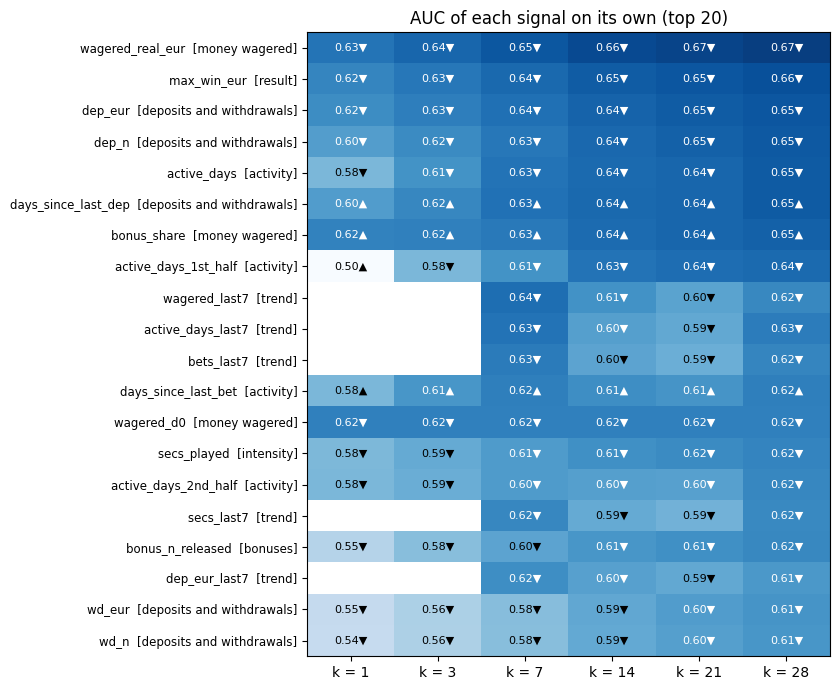

In [33]:
uni = {}
for k in KS:
    f = poblacion_k(k)
    X = matriz(f, columnas(k), k)
    uni[k] = pd.Series({c: auc(X[c], f["y"]) for c in X.columns})
uni = pd.DataFrame(uni)                                               
uni_util = np.maximum(uni, 1 - uni)
orden_uni = uni_util.max(axis=1).sort_values(ascending=False).head(20).index

fig, ax = plt.subplots(figsize=(8.5, 7))
M = uni_util.reindex(orden_uni)
ax.imshow(M.values, cmap="Blues", aspect="auto", vmin=0.5, vmax=0.68)
ax.set_xticks(range(len(KS)))
ax.set_xticklabels([f"k = {k}" for k in KS])
ax.set_yticks(range(len(orden_uni)))
ax.set_yticklabels([f"{c}  [{fam_all[c]}]" for c in orden_uni], fontsize=8.5)
for i, c in enumerate(orden_uni):
    for j, k in enumerate(KS):
        v = uni.loc[c, k]
        if np.isfinite(v):
            ax.text(j, i, f"{max(v, 1 - v):.2f}{'▲' if v >= 0.5 else '▼'}", ha="center", va="center", fontsize=8,
                    color="white" if max(v, 1 - v) > 0.6 else "black")
ax.set_title("AUC of each signal on its own (top 20)")
plt.tight_layout()
plt.show()

### AUC curve by k

Five models are compared, with the two populations: (1) only `dias_activos`, (2) the base signals **without bonuses** with gradient boosting, (3) all the base signals, **with bonuses**, (4) base + **trend** (level of the last week from k = 7, **momentum** from k = 14 and **acceleration** from k = 21) and (5) the previous one plus the tenant. The difference between (3) and (2) is what the bonuses add.

- **Momentum**: `(last week - previous week) / (last + previous)`, between -1 and +1, for active days, bets, seconds played, amount wagered and deposits. It is based on activity and not on day-to-day GGR, which is too noisy.
- **Acceleration**: momentum of the last week minus the momentum of the previous week.
- Weeks are 7 days long and do not include day 0, which is the day of the first bet and behaves differently.

For k < 7 there are no trend signals, and "base + trend" is the same as "base signals".

In [34]:
filas, modelos_curva = [], {}
for k in KS:
    for pob in POBLACIONES:
        d = poblacion_k(k, pob)
        corte_k = d["fb"].sort_values().iloc[int(len(d) * 0.7)]
        tr, te = d["fb"] <= corte_k, d["fb"] > corte_k
        variantes = {
            "active days only": (["active_days"], "logit", False),
            "base without bonuses": ([c for c in columnas(k, False) if FAMILY[c] != "bonuses"], "gbm", False),
            "base signals": (columnas(k, False), "gbm", False),
            "base + trend": (columnas(k, True), "gbm", False),
            "base + trend + tenant": (columnas(k, True), "gbm", True),
        }
        for nombre, (cols, modelo, ten) in variantes.items():
            if nombre == "base + trend" and k < 7:
                continue
            m, X, p = ajustar(d, cols, k, tr, te, modelo, ten)
            est, lo, hi = auc_ic(d.loc[te, "y"], p)
            filas.append({"k": k, "population": pob, "model": nombre, "AUC": est, "lo": lo, "hi": hi,
                          "n": len(d), "n_test": int(te.sum()), "%churn": d["y"].mean() * 100})
            if nombre == ("base + trend" if k >= 7 else "base signals"):
                modelos_curva[(pob, k)] = (m, X.loc[te], d.loc[te, "y"])      # the model explained with SHAP
curva = pd.DataFrame(filas)
print("Players in each population (n):")
print(curva.drop_duplicates(["k", "population"]).pivot_table(index="population", columns="k", values="n").astype(int).to_string())
print(f"\nTest players per model: from {curva['n_test'].min():,} to {curva['n_test'].max():,} | mean half-width of the 95% CI: ±{((curva['hi'] - curva['lo']) / 2).mean():.3f}")
print("\nAUC in test:")
curva.pivot_table(index=["population", "model"], columns="k", values="AUC").round(3)

Players in each population (n):
k                             1      3      7      14     21     28
population                                                         
active in the last 7 days  23175  23176  12722   9302   8553   7071
all scored players         23178  23178  23178  23178  23178  23178

Test players per model: from 2,081 to 6,711 | mean half-width of the 95% CI: ±0.013

AUC in test:


k                                                   1      3      7      14     21     28
population                model                                                          
active in the last 7 days active days only       0.598  0.631  0.627  0.704  0.727  0.761
                          base + trend             NaN    NaN  0.684  0.729  0.761  0.782
                          base + trend + tenant  0.741  0.747  0.673  0.716  0.756  0.785
                          base signals           0.720  0.729  0.685  0.727  0.758  0.782
                          base without bonuses   0.703  0.709  0.670  0.721  0.749  0.780
all scored players        active days only       0.598  0.631  0.659  0.666  0.671  0.680
                          base + trend             NaN    NaN  0.750  0.760  0.791  0.823
                          base + trend + tenant  0.740  0.748  0.761  0.775  0.812  0.844
                          base signals           0.720  0.730  0.750  0.763  0.794  0.826
                          base without bonuses   0.704  0.712  0.727  0.740  0.755  0.776

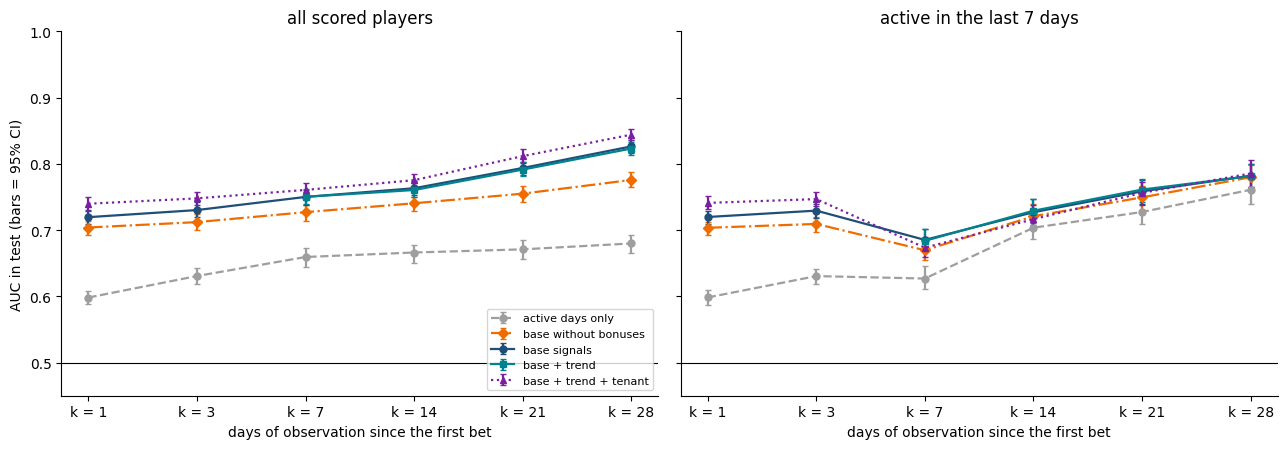

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
estilo = {"active days only": ("#9e9e9e", "o", "--"), "base without bonuses": ("#ef6c00", "D", "-."), "base signals": ("#1f4e79", "o", "-"),
          "base + trend": ("#00838f", "s", "-"), "base + trend + tenant": ("#7b1fa2", "^", ":")}
for ax, pob in zip(axes, POBLACIONES):
    for nombre, (color, marca, ls) in estilo.items():
        s = curva[(curva["population"] == pob) & (curva["model"] == nombre)].sort_values("k")
        pos = [KS.index(k) for k in s["k"]]
        ax.errorbar(pos, s["AUC"], yerr=[s["AUC"] - s["lo"], s["hi"] - s["AUC"]], color=color, marker=marca, ls=ls,
                    capsize=2, linewidth=1.6, markersize=5, label=nombre)
    ax.set_xticks(range(len(KS)))
    ax.set_xticklabels([f"k = {k}" for k in KS])
    ax.axhline(0.5, color="black", linewidth=0.8)
    ax.set_title(pob)
    ax.set_ylim(0.45, 1)
    ax.set_xlabel("days of observation since the first bet")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("AUC in test (bars = 95% CI)")
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

### SHAP: which signals weigh and in which direction

Permutation importance says *how much* a signal weighs, but not *in which direction* or *for which values*. **SHAP values** distribute the prediction of the model for each player among the signals: each signal receives a contribution (in log-odds of `Churned`) and the sum of all of them plus the base value is exactly what the model predicts. Positive contribution = pushes towards churn; negative = towards staying.

We explain the same model as in the curve (`base + trend`, without tenant), trained with the players who joined earlier and explained **on the test players**, for each k and both populations.

In [36]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")   # cosmetic tqdm warning inside Jupyter
import shap


def shap_por_k(pob):
    """Exact SHAP values (TreeExplainer) of the curve model, for each k.
    Returns {k: (test signals, SHAP, base value, test label, model)}."""
    out = {}
    for k in KS:
        m, Xt, yt = modelos_curva[(pob, k)]
        expl = shap.TreeExplainer(m)
        out[k] = (Xt, expl.shap_values(Xt), float(np.ravel(expl.expected_value)[0]), yt, m)
    return out


shap_todos, shap_activos = shap_por_k(POBLACIONES[0]), shap_por_k(POBLACIONES[1])

# Checks: (1) SHAP adds up exactly to what the model predicts, (2) it is the same model as the one in the curve
Xt, sv, base, yt, m = shap_todos[28]
print(f"k = 28, all scored players: {len(Xt):,} test players, {Xt.shape[1]} signals")
print(f"additivity: max |sum of SHAP + base - model prediction| = {np.abs(sv.sum(axis=1) + base - m.decision_function(Xt)).max():.2e} (log-odds)")
auc_curva = curva[(curva['k'] == 28) & (curva['population'] == POBLACIONES[0]) & (curva['model'] == 'base + trend')]['AUC'].iloc[0]
print(f"AUC in test of this model: {roc_auc_score(yt, m.predict_proba(Xt)[:, 1]):.3f} (the one in the curve for k = 28: {auc_curva:.3f})")

k = 28, all scored players: 6,711 test players, 53 signals
additivity: max |sum of SHAP + base - model prediction| = 5.77e-15 (log-odds)
AUC in test of this model: 0.823 (the one in the curve for k = 28: 0.823)


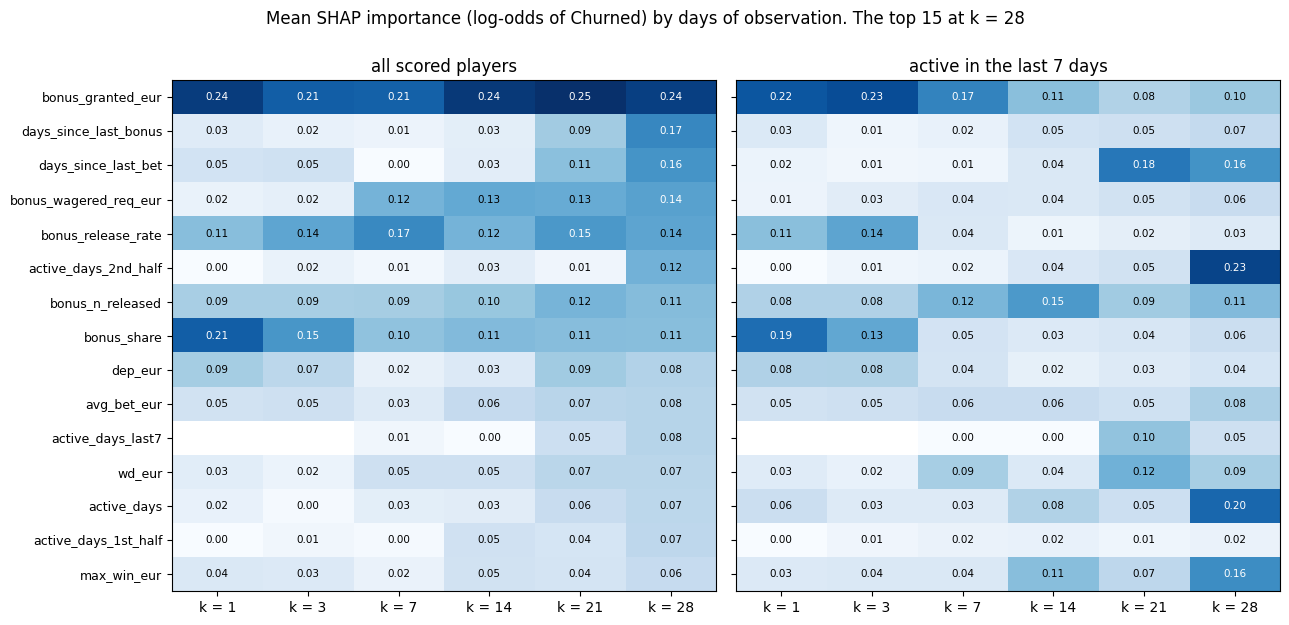

In [37]:
def imp_shap(res):
    return pd.DataFrame({k: pd.Series(np.abs(sv).mean(axis=0), index=Xt.columns) for k, (Xt, sv, _, _, _) in res.items()})


imp_todos, imp_activos = imp_shap(shap_todos), imp_shap(shap_activos)
orden = imp_todos[28].sort_values(ascending=False).head(15).index

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True)
vmax = max(imp_todos.reindex(orden).max().max(), imp_activos.reindex(orden).max().max())
for ax, (nombre, imp) in zip(axes, [(POBLACIONES[0], imp_todos), (POBLACIONES[1], imp_activos)]):
    M = imp.reindex(orden)
    ax.imshow(M.values, cmap="Blues", aspect="auto", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(KS)))
    ax.set_xticklabels([f"k = {k}" for k in KS])
    ax.set_yticks(range(len(orden)))
    ax.set_yticklabels(orden, fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.55 * vmax else "black")
    ax.set_title(nombre)
fig.suptitle("Mean SHAP importance (log-odds of Churned) by days of observation. The top 15 at k = 28", y=1.0)
plt.tight_layout()
plt.show()

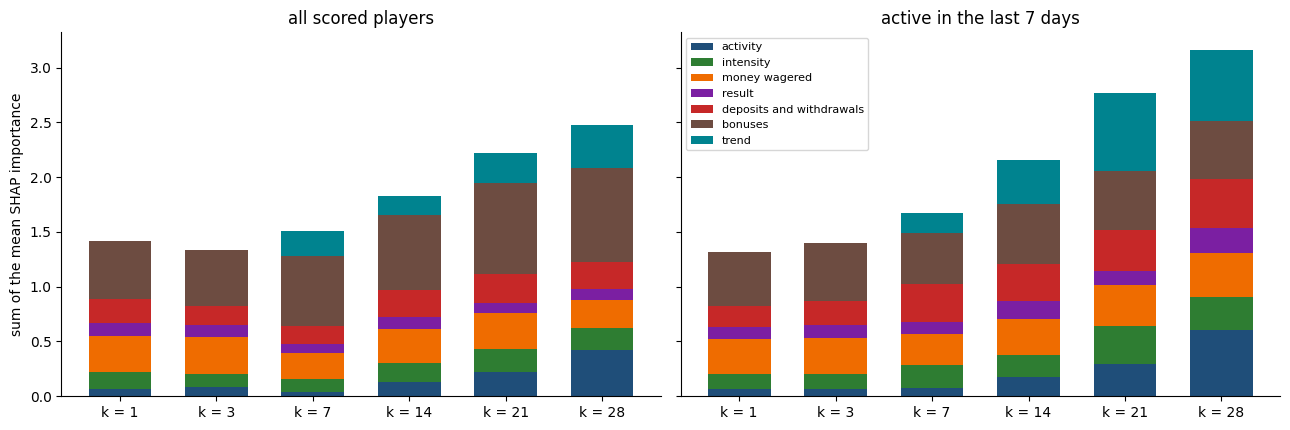

Percentage of the total SHAP importance contributed by each family:


k = 1  k = 3  k = 7  k = 14  k = 21  k = 28
all scored players        activity                      5      6      2       7      10      17
                          intensity                    11      9      8       9      10       8
                          money wagered                23     25     16      17      15      10
                          result                        9      8      5       6       4       4
                          deposits and withdrawals     15     13     11      13      12      10
                          bonuses                      37     39     42      38      37      35
                          trend                         0      0     15       9      13      16
active in the last 7 days activity                      5      5      5       8      11      19
                          intensity                    10     10     13       9      12      10
                          money wagered                24     23     17      15      14      13
                          result                        8      8      7       8       4       7
                          deposits and withdrawals     14     16     21      16      14      14
                          bonuses                      38     38     28      25      19      17
                          trend                         0      0     11      19      26      21

In [38]:
orden_fam = ["activity", "intensity", "money wagered", "result", "deposits and withdrawals", "bonuses", "trend"]
por_familia = {nombre: imp.groupby(imp.index.map(fam_all)).sum().reindex(orden_fam).fillna(0)
               for nombre, imp in [(POBLACIONES[0], imp_todos), (POBLACIONES[1], imp_activos)]}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (nombre, fam) in zip(axes, por_familia.items()):
    abajo = np.zeros(len(KS))
    for f_ in orden_fam:
        ax.bar(range(len(KS)), fam.loc[f_].values, bottom=abajo, color=COLOR_FAMILIA[f_], label=f_, width=0.65)
        abajo += fam.loc[f_].values
    ax.set_xticks(range(len(KS)))
    ax.set_xticklabels([f"k = {k}" for k in KS])
    ax.set_title(nombre)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("sum of the mean SHAP importance")
axes[1].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

reparto = pd.concat({n: fam / fam.sum() * 100 for n, fam in por_familia.items()}).round(0).astype(int)
reparto.columns = [f"k = {k}" for k in KS]
print("Percentage of the total SHAP importance contributed by each family:")
reparto

**What each signal does at 28 days** (all scored players). Each point is a test player. Horizontal axis: contribution to the prediction (right = towards churn). Colour: value of the signal (red = high, blue = low). The "no deposit" values are coded out of range, so they appear as the high end.

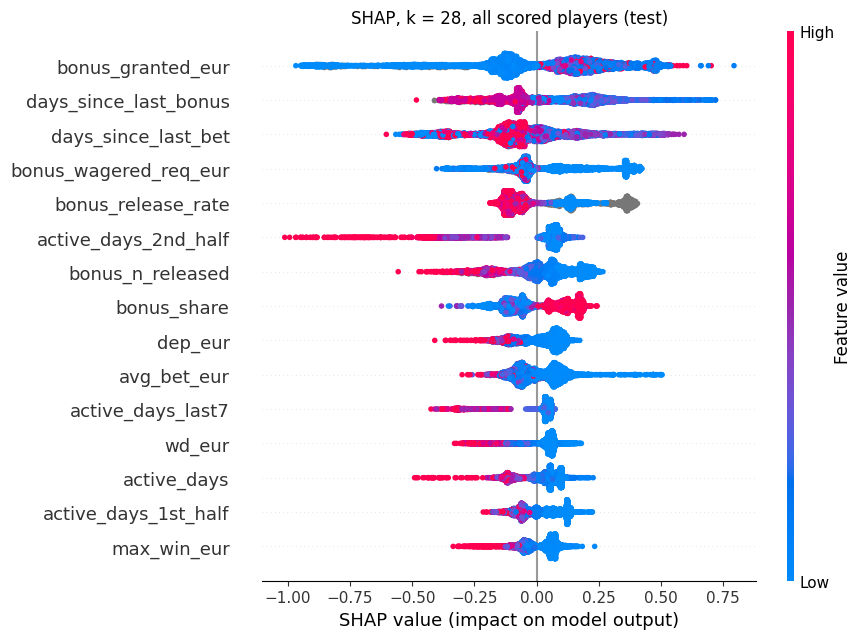

In [39]:
Xt, sv, base, yt, m = shap_todos[28]
shap.summary_plot(sv, Xt, max_display=15, show=False, plot_size=(9, 6.5))
plt.title("SHAP, k = 28, all scored players (test)")
plt.tight_layout()
plt.show()

**Shape of the effect of the main signals.** Each point is a player: value of the signal (horizontal axis) against its SHAP contribution (vertical axis). It helps to see thresholds and non-linear effects. The 1% most extreme values of each horizontal axis are trimmed.

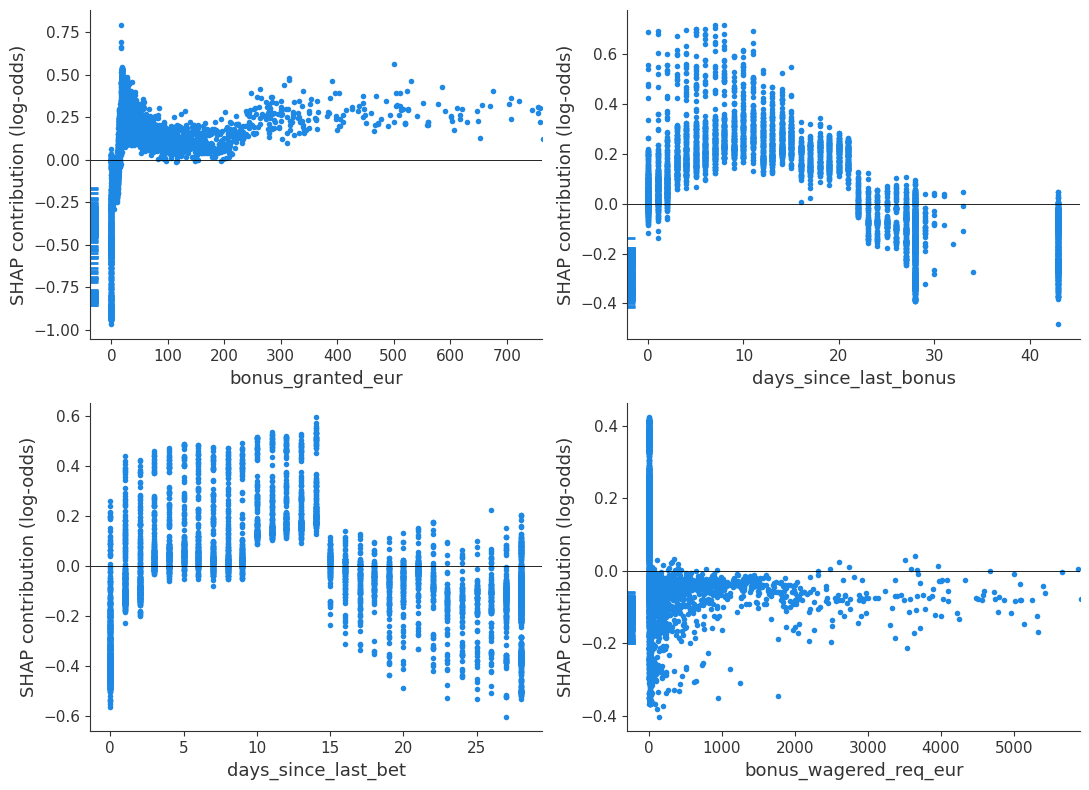

In [40]:
Xt, sv, base, yt, m = shap_todos[28]
top4 = list(pd.Series(np.abs(sv).mean(axis=0), index=Xt.columns).sort_values(ascending=False).index[:4])
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, c in zip(axes.ravel(), top4):
    shap.dependence_plot(c, sv, Xt, ax=ax, show=False, interaction_index=None, xmin="percentile(1)", xmax="percentile(99)")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("SHAP contribution (log-odds)")
plt.tight_layout()
plt.show()

### Results of the early churn study

**The data.** Of 130,668 new players, production only scores 17.8% on their day 60 (23,178 without counting the sign-up spike). The remaining 82% is `Not Scored`, with a median of 1 active day in the first week. Among the scored players, 58.4% are `Churned`. Being scoreable depends on activity: 10.5% of those who play a single day in the first week are scored, against 63.9% of those who play 4 days or more. That is why the results only apply to players that production ends up scoring. Bonuses reach almost the whole cohort: 88.8% received some bonus between 14 days before the first bet and day 7 (where there are bonus data). One tenant (3,639 players, 709 of them scored) has no bonus rows at all and its bonus signals are empty.

**A discard before modelling: the active bonus balance.** Besides the bonus flows (granted, released, expired), `gld_player_bonus_daily` has the active bonus balance (`active_bonus_balance_eur`). Its two signals (`bonus_balance_max_eur` and `days_with_active_bonus`) **change direction between training and test**: their AUC goes from 0.42 to 0.63 and from 0.42 to 0.62, that is, more balance goes from "less churn" to "more churn". Since the week of 6 July, in some tenants (for example `brand 14`, `brand 96` and `brand 23`) the days with balance go from a mean of 1.5 to 2.5 to between 4.5 and 6. In a first test with them, the AUC in test at k = 1 dropped from 0.70 to 0.60 when the bonuses were added. They are left out (they are calculated, but they do not enter any family), and in addition the schema document (`gld-schemas.xlsx`) marks the balance as a state and not a flow, and removes it from the table. The flow signals do not change direction (table of the check).

**Each signal on its own is worth little.** The best is still `wagered_real_eur` (more real money wagered, less churn): AUC 0.63 at k = 1 and 0.67 at k = 28. It is followed by `max_win_eur` (0.66 at k = 28) and `dep_eur`, `active_days`, `days_since_last_dep` and `bonus_share` (0.65). Among the bonuses, the best on its own is `bonus_n_released` (bonuses released: 0.55 at k = 1 and 0.62 at k = 28), followed by `bonus_released_eur` (0.61) and `bonus_wagered_req_eur` (0.60). `bonus_granted_eur` is worth only 0.55 and, even so, it is the most important signal of the model, because its effect is not linear (like `ggr_eur`, which is worth 0.51 to 0.55 on its own).

**Bonuses improve the model, and more so the more days pass.** Among all scored players, the base signals with bonuses go from 0.720 (k = 1) to 0.826 (k = 28); without the bonus signals, from 0.704 to 0.776. Bonuses add +0.016 at k = 1, +0.018 at k = 3, +0.023 at k = 7 and k = 14, +0.039 at k = 21 and +0.051 at k = 28. With only `active_days` the AUC goes from 0.598 to 0.680, so the rest of the signals add between +0.09 and +0.15. Among those who are still playing, bonuses add +0.016 to +0.020 up to k = 7 and almost nothing afterwards (+0.006, +0.009 and +0.002 at k = 14, 21 and 28).

**Among those who are still playing, almost everything is "active days".** In the population of those who bet in the last 7 days, the AUC reaches 0.782 at k = 28, but with only `active_days` it is already 0.761: the other signals add between +0.02 and +0.03 from k = 14. The advantage is large at the beginning (+0.12 at k = 1) and almost disappears once we know how many days the player has played. The drop at k = 7 (0.685) is due to that population leaving out those who did not come back after the first day, a harder problem.

**Momentum and acceleration add nothing.** Adding the trend signals (level of the last week, momentum and acceleration) changes the AUC by between -0.003 and +0.003 at all k and populations. On their own they are worth little: 0.50 to 0.54 for momentum and 0.50 to 0.51 for acceleration (columns `AUC_k7` and `AUC_k28` of the table in Section 6). The level of the last week does have some signal (0.59 to 0.64, less activity = more churn), but `active_days` and `days_since_last_bet` already capture it.

**The tenant weighs less than before.** Adding it raises the AUC by between +0.01 and +0.02 among all scored players (before including the bonuses it was +0.03 to +0.04: part of what the tenant contributed is now captured by the bonus signals, probably because they reflect the policy of each operator). Among those who are still playing it adds nothing from k = 7.

**What SHAP says**
- **It is the same model, explained exactly**: the sum of the contributions plus the base value matches the prediction (error of 6e-15 in log-odds) and the AUC in test is the one of the curve.
- **The bonus signals concentrate the importance**: 37% at k = 1 and 35% at k = 28 among all scored players (38% and 17% among those who are still playing). The main one is `bonus_granted_eur` (0.24 at k = 1 and at k = 28). At k = 1 it is followed by `bonus_share` (0.21); at k = 28, by `days_since_last_bonus` (0.17), `days_since_last_bet` (0.16), `bonus_wagered_req_eur` and `bonus_release_rate` (0.14 each) and `active_days_2nd_half` (0.12).
- **What matters changes over time.** Money wagered goes from 23% of the importance at k = 1 to 10% at k = 28, while activity goes up from 5% to 17%. Among those who are still playing, bonuses go down from 38% to 17% and activity takes over: `active_days_2nd_half` (0.23), `active_days` (0.20), `max_win_eur`, `wagered_real_eur` and `days_since_last_bet` (0.16 each).
- **The total information grows with the days**: the sum of importances goes from 1.42 at k = 1 to 2.48 at k = 28 among all scored players.

**Shape of the effect at k = 28** (all scored players)
- `bonus_granted_eur`: with up to 3.85 EUR granted (it includes those who received no bonus at all) the contribution is negative (-0.32 on average, down to -0.97); between 15 and 36 EUR it is positive (+0.31, up to +0.79) and above that it stays at +0.17 to +0.19. It is not linear, which is why it is worth little on its own.
- **Number of bonuses**: those who received no bonus have 44.5% churn; with a single bonus, 73.9% (they get a bonus and leave); with 5 or more, 47.8%.
- `bonus_n_released` (released): 69.1% churn with no bonus released against 39.8% with 5 or more. Contribution of +0.12 with 0 or 1 released and of -0.22 with 10 or more.
- `bonus_wagered_req_eur`: with less than 3.34 EUR wagered towards the requirement the contribution is +0.18 (more churn); above that, between -0.07 and -0.09.
- `days_since_last_bonus`: a recent bonus (granted between 2 and 21 days before k) pushes towards churn (+0.24, up to +0.72), and not having received more bonuses after the first week, or none at all, pushes towards staying (-0.09 to -0.16). One possible reading is that late bonuses are reactivation campaigns aimed at players who are already cooling down; it is a hypothesis, it has not been checked.
- `bonus_share`: above 42% of the amount wagered with bonus it pushes towards churn (+0.11 on average) and below it towards staying (-0.09 to -0.11). With the bonuses in the model the effect is smoother than before.

**Watch out for the trend.** SHAP attributes to it between 9% and 16% of the total importance from k = 7 among all scored players (up to 26% among those active in the last week), but removing it does not change the AUC. There is no contradiction: when two signals are correlated (`active_days_last7` and `active_days_2nd_half`), SHAP shares the credit between both, and when one is removed the other does the same job. SHAP importance is not the same as added value.

**Caveats.** The 95% confidence interval has a mean half-width of ±0.013 (test of 2,081 to 6,711 players), there is only one time split and only June and July cohorts. The tenant without bonus data (709 scored players, 3.1%) has 36.7% churn against 59.1% for the rest, and its missing value works as a marker of that tenant (contribution of -0.52 in `bonus_granted_eur`). Bonus signals depend on campaigns and we have already seen that the balance changed behaviour from June to July: it is worth checking their stability again when there are more cohorts.

## 6. Candidate variables for the baseline model

Summary of everything above in one table per variable and a short list for the first baseline model.

**How they are chosen**
1. **Importance** = mean of the absolute SHAP value across all k and both populations (where the signal exists).
2. **The trend family is left out** (level of the last week, momentum and acceleration): the models with and without it give the same AUC (±0.003), so they add nothing above the base signals even if SHAP gives them weight.
3. **The 15 most important** of the rest are taken and the **redundant ones are dropped**: if two signals have a Spearman correlation of 0.85 or more (at k = 28, all scored players), the most important one is kept.

In [41]:
N_CANDIDATAS, UMBRAL_CORR, FAMILIAS_FUERA = 15, 0.85, ["trend"]

DESDE_K = {**{c: 1 for c in FAMILY}, **{c: 7 for c in TREND7}, **{c: 14 for c in MOM}, **{c: 21 for c in ACCEL}}
resumen = pd.DataFrame({
    "family": pd.Series(fam_all),
    "from_k": pd.Series(DESDE_K),
    "SHAP_importance": pd.concat([imp_todos, imp_activos], axis=1).mean(axis=1),
    "AUC_k1": uni_util[1], "AUC_k7": uni_util[7], "AUC_k28": uni_util[28],
    "direction_k28": pd.Series(np.where(uni[28] >= 0.5, "▲ more churn", "▼ less churn"), index=uni.index),
}).sort_values("SHAP_importance", ascending=False)
resumen["ranking"] = range(1, len(resumen) + 1)

elegibles = resumen[~resumen["family"].isin(FAMILIAS_FUERA)]
candidatas = list(elegibles.index[:N_CANDIDATAS])
corr = matriz(poblacion_k(28), columnas(28), 28)[candidatas].corr(method="spearman")

decision = {c: "out: family adds nothing (trend)" for c in resumen.index[resumen["family"].isin(FAMILIAS_FUERA)]}
decision.update({c: f"out: not among the top {N_CANDIDATAS}" for c in elegibles.index[N_CANDIDATAS:]})
elegidas = []
for c in candidatas:                                          # from most to least important
    rival = next((e for e in elegidas if abs(corr.loc[c, e]) >= UMBRAL_CORR), None)
    if rival is None:
        elegidas.append(c)
        decision[c] = "SELECTED"
    else:
        decision[c] = f"redundant with {rival} (rho = {corr.loc[c, rival]:.2f})"
resumen["decision"] = pd.Series(decision)
print(f"Selected: {len(elegidas)} of {len(resumen)} variables")
resumen.head(30).round(3)

Selected: 13 of 53 variables


,family,from_k,SHAP_importance,AUC_k1,AUC_k7,AUC_k28,direction_k28,ranking,decision
bonus_granted_eur,bonuses,1,0.191,0.531,0.512,0.545,▼ less churn,1,SELECTED
bonus_share,money wagered,1,0.108,0.623,0.629,0.646,▲ more churn,2,SELECTED
bonus_n_released,bonuses,1,0.102,0.554,0.598,0.619,▼ less churn,3,SELECTED
bonus_release_rate,bonuses,1,0.097,0.503,0.523,0.574,▼ less churn,4,SELECTED
wagered_real_eur,money wagered,1,0.092,0.633,0.653,0.670,▼ less churn,5,SELECTED
days_since_last_bet,activity,1,0.067,0.583,0.625,0.625,▲ more churn,6,SELECTED
bonus_wagered_req_eur,bonuses,1,0.066,0.558,0.593,0.603,▼ less churn,7,SELECTED
days_since_last_dep,deposits and withdrawals,1,0.064,0.603,0.635,0.650,▲ more churn,8,SELECTED
ggr_eur,result,1,0.064,0.506,0.535,0.553,▼ less churn,9,SELECTED
wagered_last7,trend,7,0.064,NaN,0.637,0.619,▼ less churn,10,out: family adds nothing (trend)


### Correlation between the candidates

Spearman correlation between the 15 candidate signals (k = 28, all scored players), ordered from most to least important. It is the matrix used by the redundancy filter: a black box marks the pairs with |rho| equal to or greater than the threshold (0.85). The labels in blue are the selected signals and the grey ones, the dropped ones. Below, the most correlated pairs and what was decided in each case.

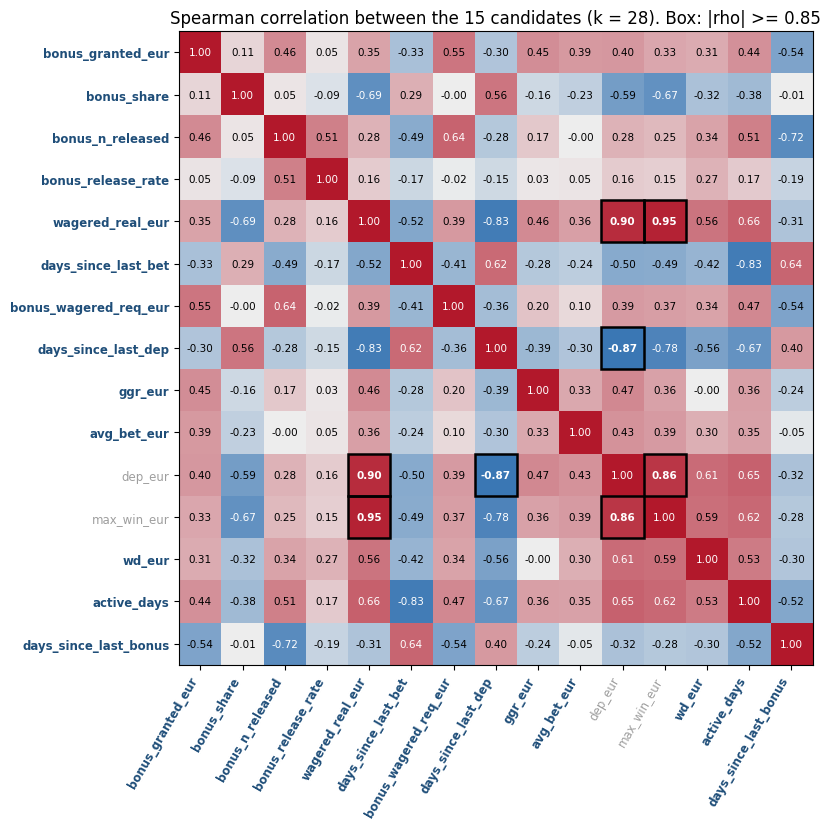

Pairs with |rho| >= 0.85: 4 of 105


,signal A,signal B,rho,decision
0,wagered_real_eur,max_win_eur,0.95,drop max_win_eur
1,wagered_real_eur,dep_eur,0.90,drop dep_eur
2,days_since_last_dep,dep_eur,-0.87,no effect (one of the two was already dropped)
3,dep_eur,max_win_eur,0.86,no effect (one of the two was already dropped)
4,wagered_real_eur,days_since_last_dep,-0.83,
5,days_since_last_bet,active_days,-0.83,
6,days_since_last_dep,max_win_eur,-0.78,
7,bonus_n_released,days_since_last_bonus,-0.72,
8,bonus_share,wagered_real_eur,-0.69,
9,bonus_share,max_win_eur,-0.67,


In [42]:
from matplotlib.colors import LinearSegmentedColormap

cmap_div = LinearSegmentedColormap.from_list("div", ["#2166ac", "#eeeeee", "#b2182b"])   # blue (negative) - grey - red (positive)
nombres_c = list(corr.index)
elegida = [resumen.loc[c, "decision"] == "SELECTED" for c in nombres_c]

fig, ax = plt.subplots(figsize=(10, 8.4))
ax.imshow(corr.values, cmap=cmap_div, vmin=-1, vmax=1)
ax.set_xticks(range(len(nombres_c)))
ax.set_yticks(range(len(nombres_c)))
ax.set_xticklabels(nombres_c, rotation=60, ha="right", fontsize=8.5)
ax.set_yticklabels(nombres_c, fontsize=8.5)
for lab_x, lab_y, ok in zip(ax.get_xticklabels(), ax.get_yticklabels(), elegida):
    for lab in (lab_x, lab_y):
        lab.set_color("#1f4e79" if ok else "#9e9e9e")
        lab.set_fontweight("bold" if ok else "normal")
for i in range(len(nombres_c)):
    for j in range(len(nombres_c)):
        v = corr.iloc[i, j]
        fuerte = i != j and abs(v) >= UMBRAL_CORR
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, fontweight="bold" if fuerte else "normal",
                color="white" if abs(v) > 0.6 else "black")
        if fuerte:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.8))
ax.set_title(f"Spearman correlation between the {len(nombres_c)} candidates (k = 28). Box: |rho| >= {UMBRAL_CORR}")
plt.tight_layout()
plt.show()

triang = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pares = (corr.where(triang).stack().rename("rho").reset_index()
         .rename(columns={"level_0": "signal A", "level_1": "signal B"}))
pares["|rho|"] = pares["rho"].abs()
pares = pares.sort_values("|rho|", ascending=False).head(12).reset_index(drop=True)


def efecto(f):
    for x, y in [(f["signal A"], f["signal B"]), (f["signal B"], f["signal A"])]:
        if str(resumen.loc[x, "decision"]).startswith(f"redundant with {y}"):
            return f"drop {x}"
    return "" if f["|rho|"] < UMBRAL_CORR else "no effect (one of the two was already dropped)"


pares["decision"] = pares.apply(efecto, axis=1)
n_fuertes = int((corr.where(triang).abs() >= UMBRAL_CORR).sum().sum())
print(f"Pairs with |rho| >= {UMBRAL_CORR}: {n_fuertes} of {len(nombres_c) * (len(nombres_c) - 1) // 2}")
pares[["signal A", "signal B", "rho", "decision"]].round(2)

In [43]:
FEATURES_BASELINE = (resumen.loc[elegidas, ["family", "from_k", "SHAP_importance", "AUC_k1", "AUC_k28", "direction_k28"]]
                     .assign(SHAP_importance=lambda x: x["SHAP_importance"].round(3), AUC_k1=lambda x: x["AUC_k1"].round(3),
                             AUC_k28=lambda x: x["AUC_k28"].round(3)))
FEATURES_BASELINE

,family,from_k,SHAP_importance,AUC_k1,AUC_k28,direction_k28
bonus_granted_eur,bonuses,1,0.191,0.531,0.545,▼ less churn
bonus_share,money wagered,1,0.108,0.623,0.646,▲ more churn
bonus_n_released,bonuses,1,0.102,0.554,0.619,▼ less churn
bonus_release_rate,bonuses,1,0.097,0.503,0.574,▼ less churn
wagered_real_eur,money wagered,1,0.092,0.633,0.670,▼ less churn
days_since_last_bet,activity,1,0.067,0.583,0.625,▲ more churn
bonus_wagered_req_eur,bonuses,1,0.066,0.558,0.603,▼ less churn
days_since_last_dep,deposits and withdrawals,1,0.064,0.603,0.650,▲ more churn
ggr_eur,result,1,0.064,0.506,0.553,▼ less churn
avg_bet_eur,money wagered,1,0.059,0.554,0.566,▼ less churn


### The selected variables

All of them are calculated from day 1 (with days 0 to k since the first bet), so they are valid for any k. Grouped:

- **Bonuses**: `bonus_granted_eur` (amount of bonuses granted; non-linear effect), `bonus_n_released` (number of bonuses released), `bonus_release_rate` (share of the already resolved bonuses that were released), `bonus_wagered_req_eur` (amount wagered towards the wagering requirement) and `days_since_last_bonus` (recency of the last bonus granted).
- **How they bet**: `bonus_share` (share of the amount wagered that comes from bonuses; more churn above 42%), `wagered_real_eur` (real money wagered) and `avg_bet_eur` (average bet).
- **How much and when they play**: `active_days` (days with some bet) and `days_since_last_bet` (recency; non-monotonic effect, read together with `active_days`).
- **Result**: `ggr_eur` (accumulated GGR; positive = the player loses; non-linear effect with a cloud of risk near 0).
- **Deposits and withdrawals**: `days_since_last_dep` (recency of the deposit) and `wd_eur` (withdrawals).

**Missing values**: without a deposit, `days_since_last_dep` = k + 15; without bets, `bonus_share` and `avg_bet_eur` = 0; without bonuses granted, the bonus signals are 0 and `days_since_last_bonus` = k + 15; `bonus_release_rate` stays empty if no bonus has been resolved. In the tenant with no bonus rows at all, all the bonus signals are empty: gradient boosting accepts that, but logistic regression needs to impute them (0, and -1 in `bonus_release_rate`) and an indicator of "no bonus data".

**Left out**: the trend family (it does not improve the AUC), `max_win_eur` and `dep_eur` (correlation of 0.95 and 0.90 with `wagered_real_eur`), the active bonus balance (`bonus_balance_max_eur`, `days_with_active_bonus`: it changes direction between training and test) and the signals that are not among the top 15 (for example `active_days_2nd_half`, `wagered_bonus_eur`, `bonus_n_granted`, `secs_played` and `bets`). The detail of each decision is in the `decision` column of the table above.

In [44]:
BASELINE_SPEC = {
    "target": "early churn: churn_band == 'Churned' on day 60 since the first bet (scored players only)",
    "cohort": f"first bet between {COHORTE_INI} and {COHORTE_FIN}, without the sign-up spikes per tenant",
    "label": "gld_player_signals_daily.churn_band on the day first bet + 60 (1 = Churned; 0 = Low, Moderate, High, Imminent)",
    "tables": {"cohort": "gld_players (first_bet_at)",
               "signals": ["gld_player_gaming_daily", "gld_player_payments_daily", "gld_player_bonus_daily"],
               "label": "gld_player_signals_daily"},
    "k_cuts": KS,
    "populations": POBLACIONES,
    "split": "by date of first bet: first 70% training, last 30% test",
    "variables": {c: {"family": r["family"], "from_k": int(r["from_k"])} for c, r in FEATURES_BASELINE.iterrows()},
    "control": "tenant_id (categorical)",
    "left_out_for_now": {"trend (level of the last week, momentum, acceleration)": "does not improve the AUC (±0.003) over the base signals"},
    "excluded": {
        "churn_score, recency_pressure, frequency_decline, value_decline, churn_propensity_raw": "they are the formula of the label (circular)",
        "deposit_recency_score": "changed definition on 1 August 2026 for inactive players and players without a deposit; it is recalculated from payments_daily",
        "lifecycle_stage": "Churned needs more than 90 days without betting: it cannot happen for new players in this period",
        "bonus_balance_max_eur, days_with_active_bonus": "active bonus balance: it changes direction between training and test (AUC 0.42 to 0.63) and the table removes it",
        "brand_id": "empty for part of the players; tenant_id is used",
    },
    "metric": "AUC in test with 95% CI (bootstrap), by k and population",
}
reference = (curva[curva["model"].isin(["active days only", "base signals"])]
             .pivot_table(index=["population", "model"], columns="k", values="AUC").round(3))
print("Variables by availability block:")
for k0, grupo in FEATURES_BASELINE.groupby("from_k"):
    print(f"  from k = {k0}: {', '.join(grupo.index)}")
print("\nReference AUC of this study (test), to compare with the baseline:")
reference


Variables by availability block:
  from k = 1: bonus_granted_eur, bonus_share, bonus_n_released, bonus_release_rate, wagered_real_eur, days_since_last_bet, bonus_wagered_req_eur, days_since_last_dep, ggr_eur, avg_bet_eur, wd_eur, active_days, days_since_last_bonus

Reference AUC of this study (test), to compare with the baseline:


k                                              1      3      7      14     21     28
population                model                                                     
active in the last 7 days active days only  0.598  0.631  0.627  0.704  0.727  0.761
                          base signals      0.720  0.729  0.685  0.727  0.758  0.782
all scored players        active days only  0.598  0.631  0.659  0.666  0.671  0.680
                          base signals      0.720  0.730  0.750  0.763  0.794  0.826

### Next step: baseline with MLflow

This notebook fixes what the baseline needs: `BASELINE_SPEC` (label, cohort, split by date, variables and excluded variables with their reason) and `reference` (AUC of this study, to compare against).

- **Models**: logistic regression on the 13 variables (interpretable baseline, with `slog` for the skewed variables) and gradient boosting (as here), one for each k = 1, 3, 7, 14, 21 and 28 and for each population.
- **What to log in MLflow**: parameters (k, population, model and hyperparameters, list of variables, dates of the cohort and of the test cut), metrics (AUC in test with its interval and the improvement over "`active_days` only"), artefacts (SHAP charts and list of variables) and, as a tag, the date range of the production snapshots used for the label.
- **Control**: `tenant_id` as a categorical variable (it raises the AUC by between +0.01 and +0.02 among all scored players).
- `mlflow` is not installed in the project environment: it has to be added to `pyproject.toml` before starting.
- **Bonuses**: one tenant has no bonus data (its signals are empty): in the logistic regression, impute and include an indicator. The active bonus balance stays out.